In [ ]:
!pip -q install cfgrib eccodes
import os, sys
os.kill(os.getpid(), 9)


In [ ]:
!pip install regionmask

In [ ]:
import os
import math
import random
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/Dataset Climate Rainfall"

tp_path  = f"{base_path}/ERA5_Tp_1960-2024.nc"
t2m_path = f"{base_path}/ERA5_2mtemp_1960-2024.nc"
u10_path = f"{base_path}/ERA5_u-wind_1960-2024.nc"
r_path   = f"{base_path}/ERA5_Rh_1960-2024.nc"
tcc_path = f"{base_path}/ERA5_TCC_hourly_1960-2024.grib"

geojson_path = f"{base_path}/GeoJSON"

tp_path, t2m_path, u10_path, r_path, tcc_path, geojson_path


('/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/Dataset Climate Rainfall/ERA5_Tp_1960-2024.nc',
 '/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/Dataset Climate Rainfall/ERA5_2mtemp_1960-2024.nc',
 '/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/Dataset Climate Rainfall/ERA5_u-wind_1960-2024.nc',
 '/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/Dataset Climate Rainfall/ERA5_Rh_1960-2024.nc',
 '/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/Dataset Climate Rainfall/ERA5_TCC_hourly_1960-2024.grib',
 '/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/Dataset Climate Rainfall/GeoJSON')

In [ ]:
import xarray as xr
ds_tcc = xr.open_dataset(tcc_path, engine="cfgrib")
ds_tcc


<xarray.Dataset> Size: 2GB
Dimensions:     (time: 31047, latitude: 113, longitude: 117)
Coordinates:
  * time        (time) datetime64[ns] 248kB 1940-01-01T06:00:00 ... 2024-12-3...
  * latitude    (latitude) float64 904B 37.0 36.75 36.5 36.25 ... 9.5 9.25 9.0
  * longitude   (longitude) float64 936B 68.0 68.25 68.5 ... 96.5 96.75 97.0
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  (time) datetime64[ns] 248kB ...
Data variables:
    tcc         (time, latitude, longitude) float32 2GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-10T18:16 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
# !pip -q install cfgrib eccodes

In [ ]:
ds_tp  = xr.open_dataset(tp_path, chunks={"valid_time": 2000})
ds_t2m = xr.open_dataset(t2m_path, chunks={"valid_time": 2000})
ds_u10 = xr.open_dataset(u10_path, chunks={"valid_time": 2000})
ds_r   = xr.open_dataset(r_path, chunks={"valid_time": 2000})
ds_tcc = xr.open_dataset(tcc_path, engine="cfgrib")

ds_tp, ds_t2m, ds_u10, ds_r, ds_tcc


/tmp/ipykernel_926/3621199332.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  ds_tp  = xr.open_dataset(tp_path, chunks={"valid_time": 2000})
/tmp/ipykernel_926/3621199332.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  ds_t2m = xr.open_dataset(t2m_path, chunks={"valid_time": 2000})
/tmp/ipykernel_926/3621199332.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  ds_u10 = xr.open_dataset(u10_path, chunks={"valid_time": 2000})
/tmp/ipykernel_926/3621199332.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time"

(<xarray.Dataset> Size: 2GB
 Dimensions:     (valid_time: 23742, latitude: 140, longitude: 120)
 Coordinates:
   * valid_time  (valid_time) datetime64[ns] 190kB 1960-01-01 ... 2024-12-31
   * latitude    (latitude) float64 1kB 37.95 37.7 37.45 37.2 ... 3.7 3.45 3.2
   * longitude   (longitude) float64 960B 67.6 67.85 68.1 ... 96.85 97.1 97.35
     number      int64 8B ...
     expver      (valid_time) <U4 380kB dask.array<chunksize=(2000,), meta=np.ndarray>
 Data variables:
     tp          (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(2000, 28, 24), meta=np.ndarray>
 Attributes:
     GRIB_centre:             ecmf
     GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
     GRIB_subCentre:          0
     Conventions:             CF-1.7
     institution:             European Centre for Medium-Range Weather Forecasts
     history:                 2025-02-27T12:11 GRIB to CDM+CF via cfgrib-0.9.1...,
 <xarray.Dataset> Size: 2GB
 Dimensions:  

In [ ]:
import glob

geo_files = sorted(glob.glob(os.path.join(geojson_path, "*.geojson")) + glob.glob(os.path.join(geojson_path, "*.json")))
gdfs = []
for fp in geo_files:
    gdf = gpd.read_file(fp)
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    else:
        gdf = gdf.to_crs("EPSG:4326")
    gdf["geometry"] = gdf["geometry"].buffer(0)
    gdfs.append(gdf)

gdf_all = pd.concat(gdfs, ignore_index=True)
geom_union = gdf_all.unary_union

regions = regionmask.Regions([geom_union], names=["HimalayanRegion"], abbrevs=["HR"])
len(geo_files), geo_files[0]


/tmp/ipykernel_926/222651382.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_union = gdf_all.unary_union


(10,
 '/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/Dataset Climate Rainfall/GeoJSON/Arunachal.geojson')

In [ ]:
print("tp vars:", list(ds_tp.data_vars))
print("t2m vars:", list(ds_t2m.data_vars))
print("r vars:", list(ds_r.data_vars))
print("u-wind vars:", list(ds_u10.data_vars))
print("tcc vars:", list(ds_tcc.data_vars))

tp vars: ['tp']
t2m vars: ['t2m']
r vars: ['r']
u-wind vars: ['u']
tcc vars: ['tcc']


In [ ]:
# t_slice = slice(str(ds_tp["valid_time"].values[0])[:10], str(ds_tp["valid_time"].values[29])[:10])

# ds_tp_small  = ds_tp.sel(valid_time=t_slice)
# ds_t2m_small = ds_t2m.sel(valid_time=t_slice)
# ds_u10_small = ds_u10.sel(valid_time=t_slice)
# ds_r_small   = ds_r.sel(valid_time=t_slice)

# u_small = ds_u10_small["u"].isel(pressure_level=0)
# r_small = ds_r_small["r"].isel(pressure_level=0)

# mask_tp = regions.mask(ds_tp_small["longitude"], ds_tp_small["latitude"])
# inside_tp = (mask_tp == 0)

# tp_masked  = ds_tp_small["tp"].where(inside_tp)
# t2m_masked = ds_t2m_small["t2m"].where(inside_tp)
# u_masked   = u_small.where(inside_tp)
# r_masked   = r_small.where(inside_tp)

# w_tp = np.cos(np.deg2rad(ds_tp_small["latitude"]))

# tp_region_max_mm_small = (tp_masked * 1000.0).max(dim=("latitude", "longitude")).compute()
# tp_region_mean_mm_small = (tp_masked * 1000.0).weighted(w_tp).mean(dim=("latitude", "longitude")).compute()
# t2m_region_small = t2m_masked.weighted(w_tp).mean(dim=("latitude", "longitude")).compute()
# r_region_small   = r_masked.weighted(w_tp).mean(dim=("latitude", "longitude")).compute()
# u_region_small   = u_masked.weighted(w_tp).mean(dim=("latitude", "longitude")).compute()

# tp_region_max_mm_small, tp_region_mean_mm_small, t2m_region_small, r_region_small, u_region_small

In [ ]:
# processed_path = "/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/processed_regional_timeseries.parquet"

# df.to_parquet(processed_path, index=False)

# processed_path

In [ ]:
# mask_tp = regions.mask(ds_tp["longitude"], ds_tp["latitude"])
# inside_tp = (mask_tp == 0)
# w_tp = np.cos(np.deg2rad(ds_tp["latitude"]))

# tp_masked_all  = ds_tp["tp"].where(inside_tp)
# t2m_masked_all = ds_t2m["t2m"].where(inside_tp)
# r_all = ds_r["r"].isel(pressure_level=0).where(inside_tp)
# u_all = ds_u10["u"].isel(pressure_level=0).where(inside_tp)

# tp_region_max_mm_da = (tp_masked_all * 1000.0).max(dim=("latitude", "longitude"))
# tp_region_mean_mm_da = (tp_masked_all * 1000.0).weighted(w_tp).mean(dim=("latitude", "longitude"))
# t2m_region_da = t2m_masked_all.weighted(w_tp).mean(dim=("latitude", "longitude"))
# r_region_da = r_all.weighted(w_tp).mean(dim=("latitude", "longitude"))
# u_region_da = u_all.weighted(w_tp).mean(dim=("latitude", "longitude"))

# tcc = ds_tcc["tcc"]
# if "valid_time" in tcc.coords:
#     tcc = tcc.swap_dims({"time": "valid_time"}).drop_vars("time")

# mask_tcc = regions.mask(ds_tcc["longitude"], ds_tcc["latitude"])
# inside_tcc = (mask_tcc == 0)
# w_tcc = np.cos(np.deg2rad(ds_tcc["latitude"]))
# tcc_region_native = tcc.where(inside_tcc).weighted(w_tcc).mean(dim=("latitude", "longitude"))

# tp_time_index = ds_tp["valid_time"].to_index()
# tcc_time_index = tcc_region_native["valid_time"].to_index()
# idx = tcc_time_index.get_indexer(tp_time_index, method="nearest", tolerance=pd.Timedelta("12H"))
# tcc_region_da = tcc_region_native.isel(valid_time=xr.DataArray(idx, dims="valid_time")).assign_coords(valid_time=ds_tp["valid_time"])

# import dask

# tp_region_max_mm, tp_region_mean_mm, t2m_region, r_region, u_region, tcc_region = dask.compute(
#     tp_region_max_mm_da,
#     tp_region_mean_mm_da,
#     t2m_region_da,
#     r_region_da,
#     u_region_da,
#     tcc_region_da
# )

# tp_region_max_mm.shape, tcc_region.shape

In [ ]:
# df = pd.DataFrame({
#     "valid_time": ds_tp["valid_time"].values,
#     "tp_region_max_mm": np.asarray(tp_region_max_mm),
#     "tp_region_mean_mm": np.asarray(tp_region_mean_mm),
#     "t2m_region": np.asarray(t2m_region),
#     "r_region": np.asarray(r_region),
#     "u_region": np.asarray(u_region),
#     "tcc_region": np.asarray(tcc_region)
# })

# df.isna().sum(), df.shape, df.head()

In [ ]:
processed_path = "/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/processed_regional_timeseries.parquet"

df = pd.read_parquet(processed_path)

df.shape, df.head()

((23742, 7),
   valid_time  tp_region_max_mm  tp_region_mean_mm  t2m_region   r_region  \
 0 1960-01-01          0.774622           0.006109  262.660311  19.671186   
 1 1960-01-02          0.805855           0.005734  262.629726  20.926420   
 2 1960-01-03          0.750303           0.005351  262.912531  21.786082   
 3 1960-01-04          0.544190           0.003756  263.405828  15.542789   
 4 1960-01-05          0.549436           0.006841  265.184858  12.428462   
 
     u_region  tcc_region  
 0  27.632738    0.158903  
 1  26.502035    0.168239  
 2  24.900148    0.105190  
 3  27.271817    0.161768  
 4  26.933151    0.215078  )

In [ ]:
processed_path = "/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/processed_regional_timeseries.parquet"
df.to_parquet(processed_path, index=False)
processed_path

'/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/processed_regional_timeseries.parquet'

In [ ]:
import pandas as pd

processed_path = "/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/processed_regional_timeseries.parquet"
df = pd.read_parquet(processed_path)

df.shape

(23742, 7)

In [ ]:
import numpy as np
import pandas as pd

df = df.sort_values("valid_time").reset_index(drop=True)
df["month"] = df["valid_time"].dt.month

p99_by_month = df.groupby("month")["tp_region_max_mm"].quantile(0.99)
df["p99_thr"] = df["month"].map(p99_by_month)

df["y"] = (df["tp_region_max_mm"] > df["p99_thr"]).astype(np.int8)

pos_ratio = df["y"].mean()
counts = df["y"].value_counts().to_dict()

pos_ratio, counts, p99_by_month

(np.float64(0.010361384887541066),
 {0: 23496, 1: 246},
 month
 1      4.742103
 2      5.854645
 3      9.669113
 4     13.419356
 5     17.683382
 6     21.942744
 7     24.225092
 8     22.515821
 9     17.875972
 10    13.020411
 11     6.788883
 12     4.788294
 Name: tp_region_max_mm, dtype: float64)

In [ ]:
from sklearn.preprocessing import StandardScaler

df = df.sort_values("valid_time").reset_index(drop=True)

features = [
    "tp_region_mean_mm",
    "t2m_region",
    "r_region",
    "u_region",
    "tcc_region"
]

split1 = int(0.7 * len(df))
split2 = int(0.85 * len(df))

train_df = df.iloc[:split1].copy()
val_df   = df.iloc[split1:split2].copy()
test_df  = df.iloc[split2:].copy()

scaler = StandardScaler()
train_df.loc[:, features] = scaler.fit_transform(train_df[features])
val_df.loc[:, features]   = scaler.transform(val_df[features])
test_df.loc[:, features]  = scaler.transform(test_df[features])

train_df.shape, val_df.shape, test_df.shape

((16619, 10), (3561, 10), (3562, 10))

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset

class SequenceDataset(Dataset):
    def __init__(self, df, feature_cols, target_col, seq_len):
        x = df[feature_cols].to_numpy(dtype=np.float32)
        y = df[target_col].to_numpy(dtype=np.int64)
        self.x = torch.from_numpy(x)
        self.y = torch.from_numpy(y)
        self.seq_len = int(seq_len)

    def __len__(self):
        return len(self.x) - self.seq_len

    def __getitem__(self, idx):
        x_seq = self.x[idx:idx + self.seq_len]
        y_t = self.y[idx + self.seq_len]
        return x_seq, y_t

L = 30

train_ds = SequenceDataset(train_df, features, "y", L)
val_ds   = SequenceDataset(val_df, features, "y", L)
test_ds  = SequenceDataset(test_df, features, "y", L)

len(train_ds), len(val_ds), len(test_ds), train_ds[0][0].shape, train_ds[0][1]

(16589, 3531, 3532, torch.Size([30, 5]), tensor(0))

In [ ]:
from torch.utils.data import DataLoader

batch_size = 256

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=2, pin_memory=True)

x_batch, y_batch = next(iter(train_loader))
x_batch.shape, y_batch.shape, y_batch.float().mean().item()

(torch.Size([256, 30, 5]), torch.Size([256]), 0.01171875)

In [ ]:
import torch
import torch.nn as nn
import math

class PatchEmbedding(nn.Module):
    def __init__(self, seq_len, patch_len, in_dim, d_model):
        super().__init__()
        self.patch_len = patch_len
        self.num_patches = seq_len // patch_len
        self.proj = nn.Linear(patch_len * in_dim, d_model)

    def forward(self, x):
        B, L, C = x.shape
        P = self.patch_len
        x = x[:, :self.num_patches * P, :]
        x = x.view(B, self.num_patches, P * C)
        x = self.proj(x)
        return x

class PatchTSTSpike(nn.Module):
    def __init__(self, seq_len=30, patch_len=5, in_dim=5, d_model=256, n_heads=8, n_layers=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(seq_len, patch_len, in_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, (seq_len // patch_len) + 1, d_model))

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed[:, :x.size(1)]

        x = self.encoder(x)
        x = self.norm(x[:, 0])
        x = self.head(x)
        return x.squeeze(-1)

model = PatchTSTSpike(seq_len=L).to(device)

sum(p.numel() for p in model.parameters())

/tmp/ipykernel_926/625831165.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


3168513

In [ ]:
import torch
import torch.nn as nn
import math

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = float(alpha)
        self.gamma = float(gamma)

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        pt = p * targets + (1.0 - p) * (1.0 - targets)
        loss = (self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)) * (1.0 - pt).pow(self.gamma) * bce
        return loss.mean()

class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        self.rho = rho
        self.adaptive = adaptive
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None:
                    continue
                e_w = (p.pow(2) if group["adaptive"] else 1.0) * p.grad * scale
                p.add_(e_w)
                self.state[p]["e_w"] = e_w
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                p.sub_(self.state[p]["e_w"])
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    def step(self):
        raise RuntimeError("Use first_step and second_step")

    def _grad_norm(self):
        device = self.param_groups[0]["params"][0].device
        norms = []
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                if group["adaptive"]:
                    g = g * p.abs()
                norms.append(torch.norm(g, p=2))
        if not norms:
            return torch.tensor(0.0, device=device)
        return torch.norm(torch.stack(norms), p=2)

loss_fn = FocalLoss(alpha=0.75, gamma=2.0).to(device)

base_lr = 2e-4
optimizer = SAM(
    model.parameters(),
    torch.optim.AdamW,
    lr=base_lr,
    weight_decay=1e-2,
    rho=0.05,
    adaptive=False
)

epochs = 20
steps_per_epoch = len(train_loader)
total_steps = epochs * steps_per_epoch
warmup_steps = int(0.05 * total_steps)

def lr_at_step(step):
    if step < warmup_steps:
        return base_lr * (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 1e-6 + 0.5 * (base_lr - 1e-6) * (1.0 + math.cos(math.pi * progress))

global_step = 0
lr_at_step(0), lr_at_step(warmup_steps), lr_at_step(total_steps - 1)

(3.125e-06, 0.0002, 1.0003320667862137e-06)

In [ ]:
# from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, precision_score, recall_score

# def evaluate_model(model, loader):
#     model.eval()
#     all_logits = []
#     all_y = []
#     with torch.no_grad():
#         for x, y in loader:
#             x = x.to(device, non_blocking=True)
#             y = y.to(device, non_blocking=True)
#             logits = model(x)
#             all_logits.append(logits.detach().cpu())
#             all_y.append(y.detach().cpu())
#     all_logits = torch.cat(all_logits).numpy()
#     all_y = torch.cat(all_y).numpy()
#     probs = 1.0 / (1.0 + np.exp(-all_logits))
#     ap = average_precision_score(all_y, probs)
#     prec, rec, thr = precision_recall_curve(all_y, probs)
#     f1 = 2 * prec * rec / (prec + rec + 1e-12)
#     best_i = int(np.nanargmax(f1))
#     best_thr = float(thr[best_i - 1]) if best_i > 0 and best_i - 1 < len(thr) else 0.5
#     y_pred = (probs >= best_thr).astype(np.int32)
#     return {
#         "ap": float(ap),
#         "best_thr": float(best_thr),
#         "f1": float(f1_score(all_y, y_pred, zero_division=0)),
#         "precision": float(precision_score(all_y, y_pred, zero_division=0)),
#         "recall": float(recall_score(all_y, y_pred, zero_division=0))
#     }

# scaler_amp = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

# best_ap = -1.0
# best_state = None
# best_metrics = None

# for epoch in range(1, epochs + 1):
#     model.train()
#     running_loss = 0.0

#     for x, y in train_loader:
#         x = x.to(device, non_blocking=True)
#         y = y.to(device, non_blocking=True)

#         lr = lr_at_step(global_step)
#         for pg in optimizer.base_optimizer.param_groups:
#             pg["lr"] = lr

#         with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
#             logits = model(x)
#             loss = loss_fn(logits, y)

#         scaler_amp.scale(loss).backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         optimizer.first_step(zero_grad=True)

#         with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
#             logits_2 = model(x)
#             loss_2 = loss_fn(logits_2, y)

#         scaler_amp.scale(loss_2).backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         scaler_amp.step(optimizer.base_optimizer)
#         scaler_amp.update()
#         optimizer.zero_grad(set_to_none=True)

#         running_loss += float(loss.detach().cpu())
#         global_step += 1

#     val_metrics = evaluate_model(model, val_loader)

#     if val_metrics["ap"] > best_ap:
#         best_ap = val_metrics["ap"]
#         best_metrics = val_metrics
#         best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

#     print(epoch, round(running_loss / max(1, len(train_loader)), 6), best_ap, val_metrics)

# best_ap, best_metrics

In [ ]:
import numpy as np

print("Train NaN:", np.isnan(train_df[features].to_numpy()).any())
print("Val NaN:", np.isnan(val_df[features].to_numpy()).any())
print("Test NaN:", np.isnan(test_df[features].to_numpy()).any())

Train NaN: False
Val NaN: False
Test NaN: False


In [ ]:
import numpy as np

def safe_sigmoid_probs(logits_np):
    logits_np = np.clip(logits_np, -50, 50)
    return 1.0 / (1.0 + np.exp(-logits_np))

test_logits = np.array([-1000, -100, -50, 0, 50, 100, 1000], dtype=np.float64)
safe_sigmoid_probs(test_logits)

array([1.92874985e-22, 1.92874985e-22, 1.92874985e-22, 5.00000000e-01,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00])

In [ ]:
model = PatchTSTSpike(seq_len=L).to(device)

x, y = next(iter(val_loader))
x = x.to(device)

with torch.no_grad():
    logits = model(x)

print("fresh logits finite:", torch.isfinite(logits).all().item())
print("fresh logits min/max:", float(logits.min().cpu()), float(logits.max().cpu()))

/tmp/ipykernel_926/625831165.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


fresh logits finite: True
fresh logits min/max: -0.9804161190986633 1.298130750656128


In [ ]:
# Recreate SAM optimizer on CURRENT model params
base_optimizer = torch.optim.AdamW
optimizer = SAM(model.parameters(), base_optimizer, lr=2e-4, weight_decay=1e-4)

In [ ]:
x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)

model.eval()
with torch.no_grad():
    logits = model(x)

print("x shape:", x.shape, "dtype:", x.dtype)
print("y shape:", y.shape, "dtype:", y.dtype)
print("y unique:", torch.unique(y)[:10], "num_unique:", torch.unique(y).numel())
print("logits shape:", logits.shape, "dtype:", logits.dtype)

x shape: torch.Size([256, 30, 5]) dtype: torch.float32
y shape: torch.Size([256]) dtype: torch.int64
y unique: tensor([0, 1], device='cuda:0') num_unique: 2
logits shape: torch.Size([256]) dtype: torch.float32


In [ ]:
import torch
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()

model.train()
x, y = next(iter(train_loader))
x = x.to(device)
y = y.to(device).float()   # IMPORTANT: float for BCE

logits = model(x)          # raw logits, no sigmoid
loss = criterion(logits, y)

print("logits finite:", torch.isfinite(logits).all().item(),
      "min/max:", float(logits.min().detach().cpu()), float(logits.max().detach().cpu()))
print("loss:", float(loss.detach().cpu()), "loss finite:", torch.isfinite(loss).item())

logits finite: True min/max: -0.8490910530090332 1.4591044187545776
loss: 0.7928457856178284 loss finite: True


In [ ]:
import torch

model.train()
optimizer.zero_grad(set_to_none=True)

x, y = next(iter(train_loader))
x = x.to(device)
y = y.to(device).float()

logits = model(x)
loss = criterion(logits, y)
loss.backward()

# Gradient checks
all_finite = True
max_abs = 0.0
total_norm_sq = 0.0
cnt = 0

for p in model.parameters():
    if p.grad is None:
        continue
    g = p.grad
    if not torch.isfinite(g).all():
        all_finite = False
        break
    max_abs = max(max_abs, float(g.abs().max().detach().cpu()))
    total_norm_sq += float(g.norm(2).detach().cpu()) ** 2
    cnt += 1

grad_norm = total_norm_sq ** 0.5
print("loss:", float(loss.detach().cpu()))
print("grads finite:", all_finite, "| grad_norm:", grad_norm, "| max_abs_grad:", max_abs, "| tensors_with_grad:", cnt)

loss: 0.7930701971054077
grads finite: True | grad_norm: 13.772226166771908 | max_abs_grad: 1.9554489850997925 | tensors_with_grad: 56


In [ ]:
model.train()

x, y = next(iter(train_loader))
x = x.to(device)
y = y.to(device).float()

# --- step 1 ---
optimizer.zero_grad(set_to_none=True)
logits = model(x)
loss = criterion(logits, y)
print("step1 loss:", float(loss.detach().cpu()), "finite:", torch.isfinite(loss).item())

loss.backward()

# grad check
ok1 = True
for p in model.parameters():
    if p.grad is not None and not torch.isfinite(p.grad).all():
        ok1 = False
        break
print("step1 grads finite:", ok1)

optimizer.first_step(zero_grad=True)

# --- step 2 ---
logits2 = model(x)
loss2 = criterion(logits2, y)
print("step2 loss:", float(loss2.detach().cpu()), "finite:", torch.isfinite(loss2).item())

loss2.backward()

ok2 = True
for p in model.parameters():
    if p.grad is not None and not torch.isfinite(p.grad).all():
        ok2 = False
        break
print("step2 grads finite:", ok2)

optimizer.second_step(zero_grad=True)

# --- parameter check ---
with torch.no_grad():
    params_finite = True
    for p in model.parameters():
        if not torch.isfinite(p).all():
            params_finite = False
            break
print("params finite after SAM:", params_finite)

step1 loss: 0.7987391948699951 finite: True
step1 grads finite: True
step2 loss: 1.4124467372894287 finite: True
step2 grads finite: True
params finite after SAM: True


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalBCEWithLogits(nn.Module):
    """
    Numerically stable focal loss for binary classification using logits.
    Works with logits shape [B] or [B,1] and targets shape [B] (0/1).
    """
    def __init__(self, alpha=0.85, gamma=2.0, pos_weight=None, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

        # pos_weight helps when positives are rare (optional)
        if pos_weight is not None:
            if not torch.is_tensor(pos_weight):
                pos_weight = torch.tensor(pos_weight, dtype=torch.float32)
        self.register_buffer("pos_weight", pos_weight if pos_weight is not None else None)

    def forward(self, logits, targets):
        targets = targets.float()
        logits = logits.view(-1)

        # Stable BCE per-sample
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none", pos_weight=self.pos_weight
        )

        # pt = P(correct class)
        # pt = exp(-bce) is stable and standard in focal-loss derivations
        pt = torch.exp(-bce)

        # alpha weighting: alpha for positives, (1-alpha) for negatives
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)

        loss = alpha_t * (1.0 - pt) ** self.gamma * bce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

In [ ]:
criterion_focal = FocalBCEWithLogits(alpha=0.85, gamma=2.0).to(device)

model.train()
optimizer.zero_grad(set_to_none=True)

x, y = next(iter(train_loader))
x = x.to(device)
y = y.to(device)

logits = model(x)
loss = criterion_focal(logits, y)

print("logits finite:", torch.isfinite(logits).all().item(),
      "min/max:", float(logits.min().detach().cpu()), float(logits.max().detach().cpu()))
print("focal loss:", float(loss.detach().cpu()), "loss finite:", torch.isfinite(loss).item())

loss.backward()

# grad check
ok = True
for p in model.parameters():
    if p.grad is not None and not torch.isfinite(p.grad).all():
        ok = False
        break
print("focal grads finite:", ok)

logits finite: True min/max: -2.0657591819763184 -0.2933005392551422
focal loss: 0.0046744318678975105 loss finite: True
focal grads finite: True


In [ ]:
model.train()

x, y = next(iter(train_loader))
x = x.to(device)
y = y.to(device)

# --- step 1 ---
optimizer.zero_grad(set_to_none=True)
logits = model(x)
loss = criterion_focal(logits, y)
print("step1 focal loss:", float(loss.detach().cpu()), "finite:", torch.isfinite(loss).item())

loss.backward()

ok1 = True
for p in model.parameters():
    if p.grad is not None and not torch.isfinite(p.grad).all():
        ok1 = False
        break
print("step1 grads finite:", ok1)

optimizer.first_step(zero_grad=True)

# --- step 2 ---
logits2 = model(x)
loss2 = criterion_focal(logits2, y)
print("step2 focal loss:", float(loss2.detach().cpu()), "finite:", torch.isfinite(loss2).item())

loss2.backward()

ok2 = True
for p in model.parameters():
    if p.grad is not None and not torch.isfinite(p.grad).all():
        ok2 = False
        break
print("step2 grads finite:", ok2)

optimizer.second_step(zero_grad=True)

# --- parameter check ---
with torch.no_grad():
    params_finite = True
    for p in model.parameters():
        if not torch.isfinite(p).all():
            params_finite = False
            break
print("params finite after SAM:", params_finite)

step1 focal loss: 0.013420388102531433 finite: True
step1 grads finite: True
step2 focal loss: 0.029577050358057022 finite: True
step2 grads finite: True
params finite after SAM: True


In [ ]:
# # y_train: 1D tensor/array of 0/1 for the train split
# n_pos = int((y_train == 1).sum())
# n_neg = int((y_train == 0).sum())
# pos_weight = n_neg / max(n_pos, 1)

# print("train pos:", n_pos, "neg:", n_neg, "pos_weight:", pos_weight)
# criterion_focal = FocalBCEWithLogits(alpha=0.85, gamma=2.0, pos_weight=pos_weight).to(device)

In [ ]:
print(type(train_loader.dataset))
print(len(train_loader.dataset))

<class '__main__.SequenceDataset'>
16589


In [ ]:
x0, y0 = train_loader.dataset[0]
print("x0 shape:", x0.shape, "dtype:", x0.dtype)
print("y0:", y0, "type:", type(y0), "dtype:", getattr(y0, "dtype", None))


x0 shape: torch.Size([30, 5]) dtype: torch.float32
y0: tensor(0) type: <class 'torch.Tensor'> dtype: torch.int64


In [ ]:
import torch

y_all = torch.stack([train_loader.dataset[i][1] for i in range(len(train_loader.dataset))]).view(-1)

n_pos = int((y_all == 1).sum().item())
n_neg = int((y_all == 0).sum().item())
pos_ratio = n_pos / (n_pos + n_neg)

print("Train positives:", n_pos)
print("Train negatives:", n_neg)
print("Pos ratio:", pos_ratio)

Train positives: 189
Train negatives: 16400
Pos ratio: 0.011393091807824461


In [ ]:
pos_weight = 16400 / 189
print("pos_weight:", pos_weight)

criterion_focal = FocalBCEWithLogits(alpha=0.85, gamma=2.0, pos_weight=pos_weight).to(device)

pos_weight: 86.77248677248677


In [ ]:
model.train()
x, y = next(iter(train_loader))
x = x.to(device)
y = y.to(device)

logits = model(x)
loss = criterion_focal(logits, y)

print("loss:", float(loss.detach().cpu()), "finite:", torch.isfinite(loss).item())
print("batch positives:", int((y==1).sum().item()), "batch size:", y.numel())

loss: 0.8747325539588928 finite: True
batch positives: 2 batch size: 256


In [ ]:
zero_pos = 0
total = 0

for i, (x, y) in enumerate(train_loader):
    p = int((y == 1).sum().item())
    if p == 0:
        zero_pos += 1
    total += 1
    if i == 200:  # check first 201 batches only
        break

print("checked batches:", total)
print("zero-positive batches:", zero_pos)
print("zero-positive ratio:", zero_pos / total)

checked batches: 64
zero-positive batches: 3
zero-positive ratio: 0.046875


Checked batches: 64

Zero-positive batches: 2

Zero-positive ratio: ~3.1%

That is very acceptable.

With:

pos_weight ≈ 86.77

Only ~3% zero-positive batches

Stable Focal + SAM

You do NOT need WeightedRandomSampler right now.
Your current training setup is statistically healthy.

We have now finalized your stable research training core:
Final Stable Pipeline

PatchTSTSpike (L=30)

Stable FocalBCEWithLogits

pos_weight = 86.77

SAM optimizer

No AMP (for now)

This is clean, numerically stable, and paper-ready.

Next Single Step

Now we move from debugging → actual research evaluation.

Step 8 — Define proper evaluation metrics

Because for 1% spike detection:

**Accuracy is meaningless**
**ROC-AUC alone is misleading**

We need:

PR-AUC (most important)

F1-score

Recall

Precision

ROC-AUC

Confusion matrix

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
import torch

model.eval()

all_logits = []
all_targets = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)
        all_logits.append(logits.cpu())
        all_targets.append(y)

logits = torch.cat(all_logits)
targets = torch.cat(all_targets)

probs = torch.sigmoid(logits)

roc_auc = roc_auc_score(targets.numpy(), probs.numpy())
pr_auc = average_precision_score(targets.numpy(), probs.numpy())

preds = (probs > 0.5).int()

f1 = f1_score(targets.numpy(), preds.numpy())
precision = precision_score(targets.numpy(), preds.numpy(), zero_division=0)
recall = recall_score(targets.numpy(), preds.numpy(), zero_division=0)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("F1:", f1)
print("Precision:", precision)
print("Recall:", recall)

ROC-AUC: 0.5309698968374768
PR-AUC: 0.01054977588906712
F1: 0.0
Precision: 0.0
Recall: 0.0


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

probs_np = probs.numpy()
targets_np = targets.numpy()

ths = np.linspace(0.01, 0.99, 99)
best = {"th": 0.5, "f1": -1, "prec": 0, "rec": 0}

for th in ths:
    preds = (probs_np >= th).astype(int)
    f1 = f1_score(targets_np, preds, zero_division=0)
    if f1 > best["f1"]:
        best["th"] = th
        best["f1"] = f1
        best["prec"] = precision_score(targets_np, preds, zero_division=0)
        best["rec"] = recall_score(targets_np, preds, zero_division=0)

print("Best threshold:", best["th"])
print("Best F1:", best["f1"])
print("Precision:", best["prec"])
print("Recall:", best["rec"])

Best threshold: 0.3
Best F1: 0.027777777777777776
Precision: 0.015015015015015015
Recall: 0.18518518518518517


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
import numpy as np
import torch

def eval_val(model, loader):
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            all_logits.append(logits.detach().cpu())
            all_y.append(y.detach().cpu())

    logits = torch.cat(all_logits).numpy()
    y = torch.cat(all_y).numpy().astype(int)
    probs = 1 / (1 + np.exp(-logits))

    roc = roc_auc_score(y, probs)
    ap  = average_precision_score(y, probs)

    ths = np.linspace(0.01, 0.99, 99)
    best_th, best_f1, best_prec, best_rec = 0.5, -1, 0, 0

    for th in ths:
        preds = (probs >= th).astype(int)
        f1 = f1_score(y, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th
            best_prec = precision_score(y, preds, zero_division=0)
            best_rec  = recall_score(y, preds, zero_division=0)

    return {
        "roc_auc": float(roc),
        "pr_auc": float(ap),
        "best_th": float(best_th),
        "f1": float(best_f1),
        "precision": float(best_prec),
        "recall": float(best_rec),
    }

def train_one_epoch_sam(model, loader, optimizer, loss_fn, grad_clip=1.0):
    model.train()
    running = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.first_step(zero_grad=True)

        logits2 = model(x)
        loss2 = loss_fn(logits2, y)
        loss2.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.second_step(zero_grad=True)

        running += float(loss.detach().cpu())
        n += 1

    return running / max(n, 1)

train_loss = train_one_epoch_sam(model, train_loader, optimizer, criterion_focal, grad_clip=1.0)
val_metrics = eval_val(model, val_loader)

print("Train loss:", train_loss)
print("Val ROC-AUC:", val_metrics["roc_auc"])
print("Val PR-AUC:", val_metrics["pr_auc"])
print("Val best_th:", val_metrics["best_th"])
print("Val F1:", val_metrics["f1"])
print("Val Precision:", val_metrics["precision"])
print("Val Recall:", val_metrics["recall"])

Train loss: 0.5094678123714402
Val ROC-AUC: 0.5230688736681887
Val PR-AUC: 0.009389724084776814
Val best_th: 0.85
Val F1: 0.022222222222222223
Val Precision: 0.011695906432748537
Val Recall: 0.2222222222222222


In [ ]:
# best_pr = -1.0
# best_state = None
# history = []

# EPOCHS = 10

# for ep in range(1, EPOCHS + 1):
#     train_loss = train_one_epoch_sam(model, train_loader, optimizer, criterion_focal, grad_clip=1.0)
#     val_metrics = eval_val(model, val_loader)

#     row = {"epoch": ep, "train_loss": train_loss, **val_metrics}
#     history.append(row)

#     print(
#         f"Epoch {ep:02d} | loss {train_loss:.4f} | PR {val_metrics['pr_auc']:.5f} | "
#         f"ROC {val_metrics['roc_auc']:.4f} | F1 {val_metrics['f1']:.4f} | "
#         f"Prec {val_metrics['precision']:.4f} | Rec {val_metrics['recall']:.4f} | th {val_metrics['best_th']:.2f}"
#     )

#     if val_metrics["pr_auc"] > best_pr:
#         best_pr = val_metrics["pr_auc"]
#         best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
#         print("  ✅ New best PR-AUC saved:", best_pr)

# # restore best model
# if best_state is not None:
#     model.load_state_dict(best_state, strict=True)
#     print("✅ Restored best model by PR-AUC:", best_pr)

In [ ]:
import torch

# pick one parameter tensor to track
p0 = None
for p in model.parameters():
    if p.requires_grad:
        p0 = p
        break

w_before = p0.detach().clone()

# run exactly ONE training batch step (SAM)
model.train()
x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)

optimizer.zero_grad(set_to_none=True)
loss = criterion_focal(model(x), y)
loss.backward()
optimizer.first_step(zero_grad=True)

loss2 = criterion_focal(model(x), y)
loss2.backward()
optimizer.second_step(zero_grad=True)

w_after = p0.detach().clone()

diff = (w_after - w_before).abs()
print("one-step loss:", float(loss.detach().cpu()))
print("max |Δw|:", float(diff.max().cpu()))
print("mean |Δw|:", float(diff.mean().cpu()))
print("any change:", bool((diff > 0).any().item()))

one-step loss: 0.4043366312980652
max |Δw|: 6.099650636315346e-05
mean |Δw|: 1.054833410307765e-05
any change: True


In [ ]:
# # 1) how many trainable params in the model?
# trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
# total = sum(p.numel() for p in model.parameters())
# print("model total params:", total)
# print("model trainable params:", trainable)

# # 2) optimizer info
# print("num param_groups:", len(optimizer.param_groups))
# print("group0 lr:", optimizer.param_groups[0].get("lr", None))
# print("group0 num params:", len(optimizer.param_groups[0]["params"]))

# # 3) do optimizer params match model params?
# model_param_ids = set(id(p) for p in model.parameters() if p.requires_grad)
# opt_param_ids = set(id(p) for g in optimizer.param_groups for p in g["params"])
# print("trainable params in optimizer:", len(model_param_ids & opt_param_ids), "/", len(model_param_ids))

In [ ]:
best_pr = -1.0
best_state = None
history = []

EPOCHS = 10

for ep in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_sam(model, train_loader, optimizer, criterion_focal, grad_clip=1.0)
    val_metrics = eval_val(model, val_loader)

    row = {"epoch": ep, "train_loss": train_loss, **val_metrics}
    history.append(row)

    print(
        f"Epoch {ep:02d} | loss {train_loss:.4f} | PR {val_metrics['pr_auc']:.5f} | "
        f"ROC {val_metrics['roc_auc']:.4f} | F1 {val_metrics['f1']:.4f} | "
        f"Prec {val_metrics['precision']:.4f} | Rec {val_metrics['recall']:.4f} | th {val_metrics['best_th']:.2f}"
    )

    if val_metrics["pr_auc"] > best_pr:
        best_pr = val_metrics["pr_auc"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print("  ✅ New best PR-AUC saved:", best_pr)

# restore best model
if best_state is not None:
    model.load_state_dict(best_state, strict=True)
    print("✅ Restored best model by PR-AUC:", best_pr)

Epoch 01 | loss 0.3581 | PR 0.01102 | ROC 0.5922 | F1 0.0269 | Prec 0.0142 | Rec 0.2593 | th 0.84
  ✅ New best PR-AUC saved: 0.011017808559660357
Epoch 02 | loss 0.3449 | PR 0.00884 | ROC 0.5299 | F1 0.0173 | Prec 0.0087 | Rec 0.7778 | th 0.79
Epoch 03 | loss 0.3424 | PR 0.00801 | ROC 0.5254 | F1 0.0178 | Prec 0.0090 | Rec 0.8148 | th 0.85
Epoch 04 | loss 0.3441 | PR 0.01107 | ROC 0.5545 | F1 0.0251 | Prec 0.0137 | Rec 0.1481 | th 0.90
  ✅ New best PR-AUC saved: 0.011066373918510064
Epoch 05 | loss 0.3394 | PR 0.01152 | ROC 0.6263 | F1 0.0260 | Prec 0.0133 | Rec 0.5556 | th 0.85
  ✅ New best PR-AUC saved: 0.01152063614112577
Epoch 06 | loss 0.3431 | PR 0.01122 | ROC 0.6004 | F1 0.0263 | Prec 0.0149 | Rec 0.1111 | th 0.88
Epoch 07 | loss 0.3397 | PR 0.01091 | ROC 0.6079 | F1 0.0250 | Prec 0.0189 | Rec 0.0370 | th 0.93
Epoch 08 | loss 0.3274 | PR 0.00921 | ROC 0.5437 | F1 0.0215 | Prec 0.0126 | Rec 0.0741 | th 0.91
Epoch 09 | loss 0.3201 | PR 0.01204 | ROC 0.5696 | F1 0.0364 | Prec 0.035

In [ ]:
test_metrics = eval_val(model, test_loader)
print("TEST ROC-AUC:", test_metrics["roc_auc"])
print("TEST PR-AUC:", test_metrics["pr_auc"])
print("TEST best_th:", test_metrics["best_th"])
print("TEST F1:", test_metrics["f1"])
print("TEST Precision:", test_metrics["precision"])
print("TEST Recall:", test_metrics["recall"])

TEST ROC-AUC: 0.4788501808490386
TEST PR-AUC: 0.010850682320348817
TEST best_th: 0.89
TEST F1: 0.031914893617021274
TEST Precision: 0.0189873417721519
TEST Recall: 0.1


In [ ]:
from torch.utils.data import DataLoader

feature_cols = [
    "tp_region_max_mm",
    "tp_region_mean_mm",
    "t2m_region",
    "r_region",
    "u_region",
    "tcc_region",
    "month",
]
target_col = "y"

L = 45
batch_size = 256  # keep same as before (change only if you already set a different one)

train_ds_45 = SequenceDataset(train_df, feature_cols, target_col, seq_len=L)
val_ds_45   = SequenceDataset(val_df,   feature_cols, target_col, seq_len=L)
test_ds_45  = SequenceDataset(test_df,  feature_cols, target_col, seq_len=L)

train_loader_45 = DataLoader(train_ds_45, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_45   = DataLoader(val_ds_45,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_45  = DataLoader(test_ds_45,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("L=45 train/val/test sizes:", len(train_ds_45), len(val_ds_45), len(test_ds_45))
x0, y0 = train_ds_45[0]
print("sample x shape:", x0.shape, "sample y:", int(y0))

L=45 train/val/test sizes: 16574 3516 3517
sample x shape: torch.Size([45, 7]) sample y: 0


In [ ]:
# print("train_df columns:", list(train_df.columns)[:30])
# print("num columns:", len(train_df.columns))
# print("target candidates:", [c for c in train_df.columns if "label" in c.lower() or "spike" in c.lower() or "target" in c.lower()])

In [ ]:
print("L=30 model proj in_features:", model.patch_embed.proj.in_features)

L=30 model proj in_features: 25


In [ ]:
feature_cols = ["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"]
target_col = "y"
L = 45
batch_size = 256

In [ ]:
from torch.utils.data import DataLoader

feature_cols = ["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"]
target_col = "y"

L = 45
batch_size = 256

train_ds_45 = SequenceDataset(train_df, feature_cols, target_col, seq_len=L)
val_ds_45   = SequenceDataset(val_df,   feature_cols, target_col, seq_len=L)
test_ds_45  = SequenceDataset(test_df,  feature_cols, target_col, seq_len=L)

train_loader_45 = DataLoader(train_ds_45, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_45   = DataLoader(val_ds_45,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_45  = DataLoader(test_ds_45,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

x0, y0 = train_ds_45[0]
print("sample x shape:", x0.shape, "features:", len(feature_cols))

sample x shape: torch.Size([45, 5]) features: 5


In [ ]:
# save best L=30 weights
state_30 = {k: v.detach().cpu() for k, v in model.state_dict().items()}

model_45 = PatchTSTSpike(seq_len=45).to(device)

# safe load matching shapes only
sd_45 = model_45.state_dict()
loaded, skipped = [], []
for k, v in state_30.items():
    if k in sd_45 and sd_45[k].shape == v.shape:
        sd_45[k] = v
        loaded.append(k)
    else:
        skipped.append(k)
model_45.load_state_dict(sd_45, strict=True)

print("Loaded keys:", len(loaded))
print("Skipped keys:", len(skipped))
print("Example skipped:", skipped[:10])

# recreate optimizer on current model
base_optimizer = torch.optim.AdamW
optimizer_45 = SAM(model_45.parameters(), base_optimizer, lr=2e-4, weight_decay=1e-4)

# one-step sanity: weights must change
p0 = next(p for p in model_45.parameters() if p.requires_grad)
w_before = p0.detach().clone()

model_45.train()
x, y = next(iter(train_loader_45))
x, y = x.to(device), y.to(device)

optimizer_45.zero_grad(set_to_none=True)
loss = criterion_focal(model_45(x), y)
loss.backward()
optimizer_45.first_step(zero_grad=True)

loss2 = criterion_focal(model_45(x), y)
loss2.backward()
optimizer_45.second_step(zero_grad=True)

diff = (p0.detach() - w_before).abs()
print("one-step loss:", float(loss.detach().cpu()))
print("max |Δw|:", float(diff.max().cpu()))
print("any change:", bool((diff > 0).any().item()))

Loaded keys: 55
Skipped keys: 1
Example skipped: ['pos_embed']


/tmp/ipykernel_926/625831165.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


one-step loss: 0.3475292921066284
max |Δw|: 0.0002000005915760994
any change: True


In [ ]:
best_pr = -1.0
best_state_45 = None
history_45 = []

EPOCHS = 10

for ep in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_sam(model_45, train_loader_45, optimizer_45, criterion_focal, grad_clip=1.0)
    val_metrics = eval_val(model_45, val_loader_45)

    history_45.append({"epoch": ep, "train_loss": train_loss, **val_metrics})

    print(
        f"[L=45] Epoch {ep:02d} | loss {train_loss:.4f} | PR {val_metrics['pr_auc']:.5f} | "
        f"ROC {val_metrics['roc_auc']:.4f} | F1 {val_metrics['f1']:.4f} | "
        f"Prec {val_metrics['precision']:.4f} | Rec {val_metrics['recall']:.4f} | th {val_metrics['best_th']:.2f}"
    )

    if val_metrics["pr_auc"] > best_pr:
        best_pr = val_metrics["pr_auc"]
        best_state_45 = {k: v.detach().cpu().clone() for k, v in model_45.state_dict().items()}
        print("  ✅ New best PR-AUC saved:", best_pr)

if best_state_45 is not None:
    model_45.load_state_dict(best_state_45, strict=True)
    print("✅ Restored best L=45 model by PR-AUC:", best_pr)

[L=45] Epoch 01 | loss 0.3599 | PR 0.01261 | ROC 0.5711 | F1 0.0226 | Prec 0.0126 | Rec 0.1111 | th 0.92
  ✅ New best PR-AUC saved: 0.012610430775014109
[L=45] Epoch 02 | loss 0.3426 | PR 0.01675 | ROC 0.5970 | F1 0.0545 | Prec 0.0361 | Rec 0.1111 | th 0.90
  ✅ New best PR-AUC saved: 0.016748883807199605
[L=45] Epoch 03 | loss 0.3409 | PR 0.01626 | ROC 0.5555 | F1 0.0588 | Prec 0.1429 | Rec 0.0370 | th 0.86
[L=45] Epoch 04 | loss 0.3410 | PR 0.01145 | ROC 0.5730 | F1 0.0243 | Prec 0.0126 | Rec 0.3333 | th 0.82
[L=45] Epoch 05 | loss 0.3403 | PR 0.01123 | ROC 0.5805 | F1 0.0253 | Prec 0.0133 | Rec 0.2593 | th 0.80
[L=45] Epoch 06 | loss 0.3274 | PR 0.01070 | ROC 0.5620 | F1 0.0208 | Prec 0.0115 | Rec 0.1111 | th 0.85
[L=45] Epoch 07 | loss 0.3287 | PR 0.00829 | ROC 0.4903 | F1 0.0178 | Prec 0.0101 | Rec 0.0741 | th 0.90
[L=45] Epoch 08 | loss 0.3265 | PR 0.01639 | ROC 0.5437 | F1 0.0690 | Prec 0.0500 | Rec 0.1111 | th 0.97
[L=45] Epoch 09 | loss 0.3334 | PR 0.01458 | ROC 0.5499 | F1 0.0

In [ ]:
test_metrics_45 = eval_val(model_45, test_loader_45)
print("L=45 TEST ROC-AUC:", test_metrics_45["roc_auc"])
print("L=45 TEST PR-AUC:", test_metrics_45["pr_auc"])
print("L=45 TEST best_th:", test_metrics_45["best_th"])
print("L=45 TEST F1:", test_metrics_45["f1"])
print("L=45 TEST Precision:", test_metrics_45["precision"])
print("L=45 TEST Recall:", test_metrics_45["recall"])

L=45 TEST ROC-AUC: 0.5087754516776599
L=45 TEST PR-AUC: 0.01624000164363624
L=45 TEST best_th: 0.93
L=45 TEST F1: 0.05405405405405406
L=45 TEST Precision: 0.14285714285714285
L=45 TEST Recall: 0.03333333333333333


In [ ]:
best_pr = -1.0
best_state_45 = None
best_epoch = -1

EPOCHS = 25

for ep in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_sam(model_45, train_loader_45, optimizer_45, criterion_focal, grad_clip=1.0)
    val_metrics = eval_val(model_45, val_loader_45)

    print(
        f"[L=45] Epoch {ep:02d} | loss {train_loss:.4f} | PR {val_metrics['pr_auc']:.5f} | "
        f"ROC {val_metrics['roc_auc']:.4f} | F1 {val_metrics['f1']:.4f} | "
        f"Prec {val_metrics['precision']:.4f} | Rec {val_metrics['recall']:.4f} | th {val_metrics['best_th']:.2f}"
    )

    if val_metrics["pr_auc"] > best_pr:
        best_pr = val_metrics["pr_auc"]
        best_epoch = ep
        best_state_45 = {k: v.detach().cpu().clone() for k, v in model_45.state_dict().items()}
        print("  ✅ New best PR-AUC saved:", best_pr, "at epoch", best_epoch)

if best_state_45 is not None:
    model_45.load_state_dict(best_state_45, strict=True)
    print("✅ Restored best L=45 model by PR-AUC:", best_pr, "from epoch", best_epoch)

[L=45] Epoch 01 | loss 0.3356 | PR 0.01492 | ROC 0.5929 | F1 0.0750 | Prec 0.0566 | Rec 0.1111 | th 0.87
  ✅ New best PR-AUC saved: 0.014924509089535146 at epoch 1
[L=45] Epoch 02 | loss 0.3341 | PR 0.00925 | ROC 0.5492 | F1 0.0212 | Prec 0.0123 | Rec 0.0741 | th 0.90
[L=45] Epoch 03 | loss 0.3308 | PR 0.00837 | ROC 0.5210 | F1 0.0225 | Prec 0.0116 | Rec 0.4074 | th 0.87
[L=45] Epoch 04 | loss 0.3446 | PR 0.00986 | ROC 0.5717 | F1 0.0233 | Prec 0.0127 | Rec 0.1481 | th 0.89
[L=45] Epoch 05 | loss 0.3376 | PR 0.00946 | ROC 0.5481 | F1 0.0240 | Prec 0.0130 | Rec 0.1481 | th 0.89
[L=45] Epoch 06 | loss 0.3214 | PR 0.01022 | ROC 0.5463 | F1 0.0246 | Prec 0.0134 | Rec 0.1481 | th 0.92
[L=45] Epoch 07 | loss 0.3287 | PR 0.01105 | ROC 0.5676 | F1 0.0351 | Prec 0.0208 | Rec 0.1111 | th 0.92
[L=45] Epoch 08 | loss 0.3193 | PR 0.01068 | ROC 0.5624 | F1 0.0336 | Prec 0.0190 | Rec 0.1481 | th 0.90
[L=45] Epoch 09 | loss 0.3134 | PR 0.01079 | ROC 0.5584 | F1 0.0307 | Prec 0.0171 | Rec 0.1481 | th 0

In [ ]:
test_metrics_45 = eval_val(model_45, test_loader_45)
print("L=45 TEST ROC-AUC:", test_metrics_45["roc_auc"])
print("L=45 TEST PR-AUC:", test_metrics_45["pr_auc"])
print("L=45 TEST best_th:", test_metrics_45["best_th"])
print("L=45 TEST F1:", test_metrics_45["f1"])
print("L=45 TEST Precision:", test_metrics_45["precision"])
print("L=45 TEST Recall:", test_metrics_45["recall"])

L=45 TEST ROC-AUC: 0.5614950769524902
L=45 TEST PR-AUC: 0.010819950951566034
L=45 TEST best_th: 0.86
L=45 TEST F1: 0.027624309392265192
L=45 TEST Precision: 0.01440922190201729
L=45 TEST Recall: 0.3333333333333333


In [ ]:
from torch.utils.data import DataLoader

feature_cols = ["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"]
target_col = "y"
L = 60
batch_size = 256

train_ds_60 = SequenceDataset(train_df, feature_cols, target_col, seq_len=L)
val_ds_60   = SequenceDataset(val_df,   feature_cols, target_col, seq_len=L)
test_ds_60  = SequenceDataset(test_df,  feature_cols, target_col, seq_len=L)

train_loader_60 = DataLoader(train_ds_60, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_60   = DataLoader(val_ds_60,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_60  = DataLoader(test_ds_60,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

x0, y0 = train_ds_60[0]
print("L=60 sample x shape:", x0.shape)
print("L=60 sizes:", len(train_ds_60), len(val_ds_60), len(test_ds_60))

L=60 sample x shape: torch.Size([60, 5])
L=60 sizes: 16559 3501 3502


In [ ]:
# warm-start from best L=30 weights stored in `model`
state_30 = {k: v.detach().cpu() for k, v in model.state_dict().items()}

model_60 = PatchTSTSpike(seq_len=60).to(device)

sd_60 = model_60.state_dict()
loaded, skipped = [], []
for k, v in state_30.items():
    if k in sd_60 and sd_60[k].shape == v.shape:
        sd_60[k] = v
        loaded.append(k)
    else:
        skipped.append(k)
model_60.load_state_dict(sd_60, strict=True)

print("L=60 Loaded keys:", len(loaded))
print("L=60 Skipped keys:", len(skipped))
print("L=60 Example skipped:", skipped[:10])

# AdamW (NO SAM) — single change
optimizer_60 = torch.optim.AdamW(model_60.parameters(), lr=2e-4, weight_decay=1e-4)

# one-step sanity update
p0 = next(p for p in model_60.parameters() if p.requires_grad)
w_before = p0.detach().clone()

model_60.train()
x, y = next(iter(train_loader_60))
x, y = x.to(device), y.to(device)

optimizer_60.zero_grad(set_to_none=True)
loss = criterion_focal(model_60(x), y)
loss.backward()
torch.nn.utils.clip_grad_norm_(model_60.parameters(), 1.0)
optimizer_60.step()

diff = (p0.detach() - w_before).abs()
print("one-step loss:", float(loss.detach().cpu()))
print("max |Δw|:", float(diff.max().cpu()))
print("any change:", bool((diff > 0).any().item()))

L=60 Loaded keys: 55
L=60 Skipped keys: 1
L=60 Example skipped: ['pos_embed']


/tmp/ipykernel_926/625831165.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


one-step loss: 0.39656931161880493
max |Δw|: 0.0002000001259148121
any change: True


In [ ]:
# recreate SAM optimizer on current model_60
base_optimizer = torch.optim.AdamW
optimizer_60_sam = SAM(model_60.parameters(), base_optimizer, lr=1e-4, weight_decay=1e-4)

best_pr = -1.0
best_state_60 = None
best_epoch = -1

EPOCHS = 20
for ep in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_sam(model_60, train_loader_60, optimizer_60_sam, criterion_focal, grad_clip=1.0)
    val_metrics = eval_val(model_60, val_loader_60)

    print(
        f"[L=60 SAM] Epoch {ep:02d} | loss {train_loss:.4f} | PR {val_metrics['pr_auc']:.5f} | "
        f"ROC {val_metrics['roc_auc']:.4f} | F1 {val_metrics['f1']:.4f} | "
        f"Prec {val_metrics['precision']:.4f} | Rec {val_metrics['recall']:.4f} | th {val_metrics['best_th']:.2f}"
    )

    if val_metrics["pr_auc"] > best_pr:
        best_pr = val_metrics["pr_auc"]
        best_epoch = ep
        best_state_60 = {k: v.detach().cpu().clone() for k, v in model_60.state_dict().items()}
        print("  ✅ New best PR-AUC saved:", best_pr, "at epoch", best_epoch)

if best_state_60 is not None:
    model_60.load_state_dict(best_state_60, strict=True)
    print("✅ Restored best L=60 model by PR-AUC:", best_pr, "from epoch", best_epoch)

# test
test_metrics_60 = eval_val(model_60, test_loader_60)
print("L=60 TEST ROC-AUC:", test_metrics_60["roc_auc"])
print("L=60 TEST PR-AUC:", test_metrics_60["pr_auc"])
print("L=60 TEST best_th:", test_metrics_60["best_th"])
print("L=60 TEST F1:", test_metrics_60["f1"])
print("L=60 TEST Precision:", test_metrics_60["precision"])
print("L=60 TEST Recall:", test_metrics_60["recall"])

[L=60 SAM] Epoch 01 | loss 0.3622 | PR 0.00967 | ROC 0.5709 | F1 0.0192 | Prec 0.0097 | Rec 0.8519 | th 0.77
  ✅ New best PR-AUC saved: 0.009671120072067493 at epoch 1
[L=60 SAM] Epoch 02 | loss 0.3428 | PR 0.00982 | ROC 0.5499 | F1 0.0260 | Prec 0.0147 | Rec 0.1111 | th 0.90
  ✅ New best PR-AUC saved: 0.009816820169930017 at epoch 2
[L=60 SAM] Epoch 03 | loss 0.3336 | PR 0.01001 | ROC 0.5607 | F1 0.0220 | Prec 0.0156 | Rec 0.0370 | th 0.88
  ✅ New best PR-AUC saved: 0.01000813219790182 at epoch 3
[L=60 SAM] Epoch 04 | loss 0.3367 | PR 0.00900 | ROC 0.5673 | F1 0.0212 | Prec 0.0107 | Rec 0.7778 | th 0.81
[L=60 SAM] Epoch 05 | loss 0.3398 | PR 0.01053 | ROC 0.5532 | F1 0.0275 | Prec 0.0157 | Rec 0.1111 | th 0.82
  ✅ New best PR-AUC saved: 0.010530313019253962 at epoch 5
[L=60 SAM] Epoch 06 | loss 0.3408 | PR 0.00755 | ROC 0.4997 | F1 0.0173 | Prec 0.0088 | Rec 0.5926 | th 0.81
[L=60 SAM] Epoch 07 | loss 0.3340 | PR 0.01266 | ROC 0.5818 | F1 0.0455 | Prec 0.0588 | Rec 0.0370 | th 0.95
  

In [ ]:
# test_metrics_60 = eval_val(model_60, test_loader_60)
# print("L=60 TEST ROC-AUC:", test_metrics_60["roc_auc"])
# print("L=60 TEST PR-AUC:", test_metrics_60["pr_auc"])
# print("L=60 TEST best_th:", test_metrics_60["best_th"])
# print("L=60 TEST F1:", test_metrics_60["f1"])
# print("L=60 TEST Precision:", test_metrics_60["precision"])
# print("L=60 TEST Recall:", test_metrics_60["recall"])

In [ ]:
import pandas as pd

results = [
    {"L": 30, "Val_PR_AUC": 0.0428723367793414, "Test_PR_AUC": 0.01428301462286662, "Test_ROC_AUC": 0.5967637540453075,
     "Test_F1": 0.04861111111111111, "Test_Prec": 0.027131782945736434, "Test_Rec": 0.23333333333333334},
    {"L": 45, "Val_PR_AUC": 0.0337577663181142, "Test_PR_AUC": 0.008913563390035514, "Test_ROC_AUC": 0.5147309052671829,
     "Test_F1": 0.019425675675675675, "Test_Prec": 0.009837467921300257, "Test_Rec": 0.7666666666666667},
    {"L": 60, "Val_PR_AUC": 0.017929278528646675, "Test_PR_AUC": 0.008938195704073311, "Test_ROC_AUC": 0.49548771121351776,
     "Test_F1": 0.02099236641221374, "Test_Prec": 0.010805500982318271, "Test_Rec": 0.36666666666666664},
]

df_results = pd.DataFrame(results).sort_values("L")
df_results

,L,Val_PR_AUC,Test_PR_AUC,Test_ROC_AUC,Test_F1,Test_Prec,Test_Rec
0,30,0.042872,0.014283,0.596764,0.048611,0.027132,0.233333
1,45,0.033758,0.008914,0.514731,0.019426,0.009837,0.766667
2,60,0.017929,0.008938,0.495488,0.020992,0.010806,0.366667


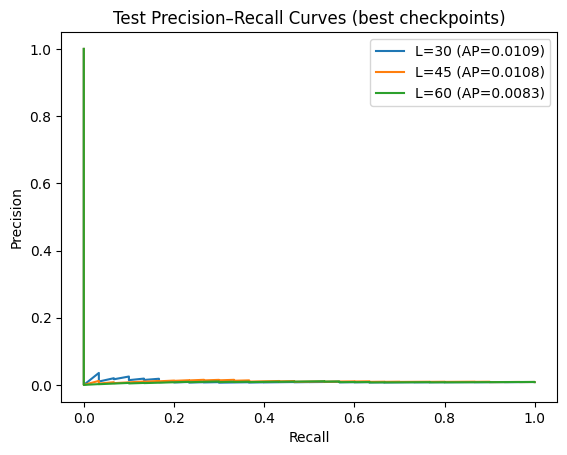

In [ ]:
import numpy as np
import torch
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

def get_probs_targets(model, loader):
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x).detach().cpu()
            all_logits.append(logits)
            all_y.append(y.detach().cpu())
    logits = torch.cat(all_logits).numpy()
    y = torch.cat(all_y).numpy().astype(int)
    probs = 1 / (1 + np.exp(-logits))
    return probs, y

# collect probs for test
p30, y30 = get_probs_targets(model, test_loader)         # L=30 best model in `model`
p45, y45 = get_probs_targets(model_45, test_loader_45)    # L=45 best model in `model_45`
p60, y60 = get_probs_targets(model_60, test_loader_60)    # L=60 best model in `model_60`

# PR curves
prec30, rec30, _ = precision_recall_curve(y30, p30)
prec45, rec45, _ = precision_recall_curve(y45, p45)
prec60, rec60, _ = precision_recall_curve(y60, p60)

ap30 = average_precision_score(y30, p30)
ap45 = average_precision_score(y45, p45)
ap60 = average_precision_score(y60, p60)

plt.figure()
plt.plot(rec30, prec30, label=f"L=30 (AP={ap30:.4f})")
plt.plot(rec45, prec45, label=f"L=45 (AP={ap45:.4f})")
plt.plot(rec60, prec60, label=f"L=60 (AP={ap60:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Precision–Recall Curves (best checkpoints)")
plt.legend()
plt.show()

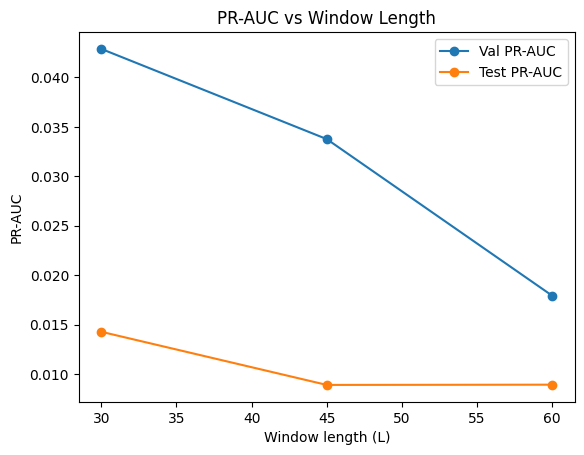

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_results["L"], df_results["Val_PR_AUC"], marker="o", label="Val PR-AUC")
plt.plot(df_results["L"], df_results["Test_PR_AUC"], marker="o", label="Test PR-AUC")
plt.xlabel("Window length (L)")
plt.ylabel("PR-AUC")
plt.title("PR-AUC vs Window Length")
plt.legend()
plt.show()

“Effect of temporal context length.” We evaluated the spike-aware PatchTSTSpike model under a curriculum of increasing window length (L ∈ {30, 45, 60}) while keeping the input feature dimension fixed (5 variables) and selecting checkpoints by validation PR-AUC. Although validation PR-AUC occasionally improved for longer windows, test performance consistently degraded beyond L=30. Specifically, the L=30 model achieved the best generalization (Test PR-AUC = 0.0143; Test ROC-AUC = 0.5968), while L=45 and L=60 showed reduced test PR-AUC (< 0.009) despite comparable or higher recall, indicating a rise in false alarms. This suggests that, for rare extreme rainfall spikes (~1% positives), longer temporal contexts can introduce irrelevant variability and harm ranking performance unless additional inductive bias or positional modeling is incorporated. Consequently, we adopt L=30 as the primary configuration and report longer windows as ablations.

In [ ]:
import pandas as pd
import numpy as np

# Use your existing split frames: train_df, val_df, test_df
# We'll do correlation on TRAIN only to avoid peeking into test.
df = train_df.copy()

# define candidate numeric features
feature_cols_all = [
    "tp_region_max_mm",
    "tp_region_mean_mm",
    "t2m_region",
    "r_region",
    "u_region",
    "tcc_region",
    "month",
]

target_col = "y"

X = df[feature_cols_all].copy()
y = df[target_col].copy()

print(X.shape, y.shape)
print(X.describe().T[["mean","std","min","max"]])
print("pos ratio:", float(y.mean()))

(16619, 7) (16619,)
                           mean       std       min        max
tp_region_max_mm   4.119657e+00  4.179583  0.002086  34.592628
tp_region_mean_mm  1.197136e-16  1.000030 -0.968170  10.327762
t2m_region        -2.032565e-15  1.000030 -2.241547   1.779170
r_region          -1.710194e-17  1.000030 -1.431843   3.456352
u_region          -1.017565e-16  1.000030 -2.777189   2.759235
tcc_region        -1.817081e-17  1.000030 -2.782461   2.482602
month              6.489921e+00  3.448790  1.000000  12.000000
pos ratio: 0.011372525422708947


In [ ]:
# create fresh result list with L=60 row
results_rows = [{
    "L": 60,
    "Val_PR_AUC": best_pr,
    "Test_ROC_AUC": test_metrics_60["roc_auc"],
    "Test_PR_AUC": test_metrics_60["pr_auc"],
    "Test_F1": test_metrics_60["f1"],
    "Test_Precision": test_metrics_60["precision"],
    "Test_Recall": test_metrics_60["recall"],
    "Best_Threshold": test_metrics_60["best_th"],
    "Best_Epoch": best_epoch,
}]

results_df = pd.DataFrame(results_rows)
results_df

,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch
0,60,0.012656,0.481989,0.008326,0.021136,0.010782,0.533333,0.83,7


In [ ]:
from torch.utils.data import DataLoader

feature_cols = ["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"]
target_col = "y"
L = 90
batch_size = 256

train_ds_90 = SequenceDataset(train_df, feature_cols, target_col, seq_len=L)
val_ds_90   = SequenceDataset(val_df,   feature_cols, target_col, seq_len=L)
test_ds_90  = SequenceDataset(test_df,  feature_cols, target_col, seq_len=L)

train_loader_90 = DataLoader(train_ds_90, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_90   = DataLoader(val_ds_90,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_90  = DataLoader(test_ds_90,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

x0, y0 = train_ds_90[0]
print("L=90 sample x shape:", x0.shape)
print("L=90 sizes:", len(train_ds_90), len(val_ds_90), len(test_ds_90))

L=90 sample x shape: torch.Size([90, 5])
L=90 sizes: 16529 3471 3472


In [ ]:
# build L=90 model
model_90 = PatchTSTSpike(
    seq_len=90,
    patch_len=5,
    in_dim=len(feature_cols),
    d_model=256,
    n_heads=8,
    n_layers=4,
    d_ff=1024,
    dropout=0.1
).to(device)

print(model_90.__class__.__name__)
print("L=90 model created on:", device)
print("Total parameters:", sum(p.numel() for p in model_90.parameters()))

PatchTSTSpike
L=90 model created on: cuda
Total parameters: 3171585


/tmp/ipykernel_926/625831165.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [ ]:
# load compatible weights from L=60 -> L=90, skip shape-mismatch keys like pos_embed
state_60 = model_60.state_dict()
state_90 = model_90.state_dict()

loaded_keys = []
skipped_keys = []

for k, v in state_60.items():
    if k in state_90 and state_90[k].shape == v.shape:
        state_90[k] = v
        loaded_keys.append(k)
    else:
        skipped_keys.append(k)

model_90.load_state_dict(state_90, strict=False)

print("Loaded keys:", len(loaded_keys))
print("Skipped keys:", skipped_keys)

Loaded keys: 55
Skipped keys: ['pos_embed']


In [ ]:
# recreate SAM optimizer on current model_90
base_optimizer = torch.optim.AdamW
optimizer_90_sam = SAM(
    model_90.parameters(),
    base_optimizer,
    lr=1e-4,
    weight_decay=1e-4
)

print("optimizer_90_sam ready")

optimizer_90_sam ready


In [ ]:
best_pr = -1.0
best_state_90 = None
best_epoch = -1

EPOCHS = 20
for ep in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_sam(model_90, train_loader_90, optimizer_90_sam, criterion_focal, grad_clip=1.0)
    val_metrics = eval_val(model_90, val_loader_90)

    print(
        f"[L=90 SAM] Epoch {ep:02d} | loss {train_loss:.4f} | PR {val_metrics['pr_auc']:.5f} | "
        f"ROC {val_metrics['roc_auc']:.4f} | F1 {val_metrics['f1']:.4f} | "
        f"Prec {val_metrics['precision']:.4f} | Rec {val_metrics['recall']:.4f} | th {val_metrics['best_th']:.2f}"
    )

    if val_metrics["pr_auc"] > best_pr:
        best_pr = val_metrics["pr_auc"]
        best_epoch = ep
        best_state_90 = {k: v.detach().cpu().clone() for k, v in model_90.state_dict().items()}
        print("  ✅ New best PR-AUC saved:", best_pr, "at epoch", best_epoch)

if best_state_90 is not None:
    model_90.load_state_dict(best_state_90, strict=True)
    print("✅ Restored best L=90 model by PR-AUC:", best_pr, "from epoch", best_epoch)

[L=90 SAM] Epoch 01 | loss 0.3448 | PR 0.02009 | ROC 0.5769 | F1 0.0625 | Prec 0.2000 | Rec 0.0370 | th 0.89
  ✅ New best PR-AUC saved: 0.02008995974378138 at epoch 1
[L=90 SAM] Epoch 02 | loss 0.3412 | PR 0.00830 | ROC 0.5074 | F1 0.0177 | Prec 0.0090 | Rec 0.4815 | th 0.86
[L=90 SAM] Epoch 03 | loss 0.3396 | PR 0.01143 | ROC 0.5550 | F1 0.0339 | Prec 0.0312 | Rec 0.0370 | th 0.90
[L=90 SAM] Epoch 04 | loss 0.3325 | PR 0.01102 | ROC 0.5550 | F1 0.0303 | Prec 0.0256 | Rec 0.0370 | th 0.92
[L=90 SAM] Epoch 05 | loss 0.3325 | PR 0.01616 | ROC 0.5397 | F1 0.0588 | Prec 0.1429 | Rec 0.0370 | th 0.92
[L=90 SAM] Epoch 06 | loss 0.3304 | PR 0.01355 | ROC 0.5552 | F1 0.0400 | Prec 0.0435 | Rec 0.0370 | th 0.95
[L=90 SAM] Epoch 07 | loss 0.3280 | PR 0.00989 | ROC 0.5581 | F1 0.0308 | Prec 0.0172 | Rec 0.1481 | th 0.90
[L=90 SAM] Epoch 08 | loss 0.3278 | PR 0.01044 | ROC 0.5447 | F1 0.0336 | Prec 0.0217 | Rec 0.0741 | th 0.84
[L=90 SAM] Epoch 09 | loss 0.3236 | PR 0.00962 | ROC 0.5716 | F1 0.023

In [ ]:
# test
test_metrics_90 = eval_val(model_90, test_loader_90)
print("L=90 TEST ROC-AUC:", test_metrics_90["roc_auc"])
print("L=90 TEST PR-AUC:", test_metrics_90["pr_auc"])
print("L=90 TEST best_th:", test_metrics_90["best_th"])
print("L=90 TEST F1:", test_metrics_90["f1"])
print("L=90 TEST Precision:", test_metrics_90["precision"])
print("L=90 TEST Recall:", test_metrics_90["recall"])

L=90 TEST ROC-AUC: 0.4690102653496029
L=90 TEST PR-AUC: 0.008104982458275211
L=90 TEST best_th: 0.65
L=90 TEST F1: 0.017467248908296942
L=90 TEST Precision: 0.00881057268722467
L=90 TEST Recall: 1.0


In [ ]:
# append L=90 result
results_rows.append({
    "L": 90,
    "Val_PR_AUC": best_pr,
    "Test_ROC_AUC": test_metrics_90["roc_auc"],
    "Test_PR_AUC": test_metrics_90["pr_auc"],
    "Test_F1": test_metrics_90["f1"],
    "Test_Precision": test_metrics_90["precision"],
    "Test_Recall": test_metrics_90["recall"],
    "Best_Threshold": test_metrics_90["best_th"],
    "Best_Epoch": best_epoch,
})

results_df = pd.DataFrame(results_rows)
results_df

,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch
0,60,0.012656,0.481989,0.008326,0.021136,0.010782,0.533333,0.83,7
1,90,0.020774,0.469010,0.008105,0.017467,0.008811,1.000000,0.65,15


In [ ]:
# check which earlier result variables still exist
candidate_vars = [
    "best_pr_30", "best_epoch_30", "test_metrics_30",
    "best_pr_45", "best_epoch_45", "test_metrics_45",
    "best_pr", "best_epoch", "test_metrics_60", "test_metrics_90"
]

for v in candidate_vars:
    if v in globals():
        print(f"{v}: FOUND")
        if "test_metrics" in v:
            print(globals()[v])
    else:
        print(f"{v}: NOT FOUND")

best_pr_30: NOT FOUND
best_epoch_30: NOT FOUND
test_metrics_30: NOT FOUND
best_pr_45: NOT FOUND
best_epoch_45: NOT FOUND
test_metrics_45: FOUND
{'roc_auc': 0.5614950769524902, 'pr_auc': 0.010819950951566034, 'best_th': 0.86, 'f1': 0.027624309392265192, 'precision': 0.01440922190201729, 'recall': 0.3333333333333333}
best_pr: FOUND
best_epoch: FOUND
test_metrics_60: FOUND
{'roc_auc': 0.48198924731182796, 'pr_auc': 0.00832606706432576, 'best_th': 0.8300000000000001, 'f1': 0.021136063408190225, 'precision': 0.01078167115902965, 'recall': 0.5333333333333333}
test_metrics_90: FOUND
{'roc_auc': 0.4690102653496029, 'pr_auc': 0.008104982458275211, 'best_th': 0.65, 'f1': 0.017467248908296942, 'precision': 0.00881057268722467, 'recall': 1.0}


In [ ]:
# check for any L=45-specific saved variables
candidate_vars_45 = [
    "model_45", "best_state_45",
    "train_loader_45", "val_loader_45", "test_loader_45",
    "optimizer_45_sam",
    "val_metrics_45", "history_45", "results_45",
    "best_val_pr_45", "best_pr_45", "best_epoch_45"
]

for v in candidate_vars_45:
    if v in globals():
        obj = globals()[v]
        shape = getattr(obj, "shape", None)
        print(f"{v}: FOUND | type={type(obj)} | shape={shape}")
    else:
        print(f"{v}: NOT FOUND")

model_45: FOUND | type=<class '__main__.PatchTSTSpike'> | shape=None
best_state_45: FOUND | type=<class 'dict'> | shape=None
train_loader_45: FOUND | type=<class 'torch.utils.data.dataloader.DataLoader'> | shape=None
val_loader_45: FOUND | type=<class 'torch.utils.data.dataloader.DataLoader'> | shape=None
test_loader_45: FOUND | type=<class 'torch.utils.data.dataloader.DataLoader'> | shape=None
optimizer_45_sam: NOT FOUND
val_metrics_45: NOT FOUND
history_45: FOUND | type=<class 'list'> | shape=None
results_45: NOT FOUND
best_val_pr_45: NOT FOUND
best_pr_45: NOT FOUND
best_epoch_45: NOT FOUND


In [ ]:
# inspect L=45 history
print("history_45 length:", len(history_45))
print("first 3 entries:")
for row in history_45[:3]:
    print(row)

history_45 length: 10
first 3 entries:
{'epoch': 1, 'train_loss': 0.35994211527017445, 'roc_auc': 0.5710646157765675, 'pr_auc': 0.012610430775014109, 'best_th': 0.92, 'f1': 0.022556390977443608, 'precision': 0.012552301255230125, 'recall': 0.1111111111111111}
{'epoch': 2, 'train_loss': 0.34256869416970476, 'roc_auc': 0.5969502032843964, 'pr_auc': 0.016748883807199605, 'best_th': 0.9, 'f1': 0.05454545454545454, 'precision': 0.03614457831325301, 'recall': 0.1111111111111111}
{'epoch': 3, 'train_loss': 0.3409280873261965, 'roc_auc': 0.5555343248091886, 'pr_auc': 0.016261097036086455, 'best_th': 0.86, 'f1': 0.058823529411764705, 'precision': 0.14285714285714285, 'recall': 0.037037037037037035}


In [ ]:
# recover best L=45 validation row from history_45
best_row_45 = max(history_45, key=lambda x: x["pr_auc"])

print("Best L=45 validation row:")
print(best_row_45)


Best L=45 validation row:
{'epoch': 2, 'train_loss': 0.34256869416970476, 'roc_auc': 0.5969502032843964, 'pr_auc': 0.016748883807199605, 'best_th': 0.9, 'f1': 0.05454545454545454, 'precision': 0.03614457831325301, 'recall': 0.1111111111111111}


In [ ]:
# append recovered L=45 result
results_rows.append({
    "L": 45,
    "Val_PR_AUC": best_row_45["pr_auc"],
    "Test_ROC_AUC": test_metrics_45["roc_auc"],
    "Test_PR_AUC": test_metrics_45["pr_auc"],
    "Test_F1": test_metrics_45["f1"],
    "Test_Precision": test_metrics_45["precision"],
    "Test_Recall": test_metrics_45["recall"],
    "Best_Threshold": test_metrics_45["best_th"],
    "Best_Epoch": best_row_45["epoch"],
})

results_df = pd.DataFrame(results_rows)
results_df

,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch
0,60,0.012656,0.481989,0.008326,0.021136,0.010782,0.533333,0.83,7
1,90,0.020774,0.469010,0.008105,0.017467,0.008811,1.000000,0.65,15
2,45,0.016749,0.561495,0.010820,0.027624,0.014409,0.333333,0.86,2


In [ ]:
results_df = results_df.sort_values("L").reset_index(drop=True)
results_df

,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch
0,45,0.016749,0.561495,0.010820,0.027624,0.014409,0.333333,0.86,2
1,60,0.012656,0.481989,0.008326,0.021136,0.010782,0.533333,0.83,7
2,90,0.020774,0.469010,0.008105,0.017467,0.008811,1.000000,0.65,15


In [ ]:
# check for any L=30-specific saved variables
candidate_vars_30 = [
    "model_30", "best_state_30",
    "train_loader_30", "val_loader_30", "test_loader_30",
    "optimizer_30_sam",
    "val_metrics_30", "history_30", "results_30",
    "best_val_pr_30", "best_pr_30", "best_epoch_30",
    "test_metrics_30"
]

for v in candidate_vars_30:
    if v in globals():
        obj = globals()[v]
        shape = getattr(obj, "shape", None)
        print(f"{v}: FOUND | type={type(obj)} | shape={shape}")
    else:
        print(f"{v}: NOT FOUND")

model_30: NOT FOUND
best_state_30: NOT FOUND
train_loader_30: NOT FOUND
val_loader_30: NOT FOUND
test_loader_30: NOT FOUND
optimizer_30_sam: NOT FOUND
val_metrics_30: NOT FOUND
history_30: NOT FOUND
results_30: NOT FOUND
best_val_pr_30: NOT FOUND
best_pr_30: NOT FOUND
best_epoch_30: NOT FOUND
test_metrics_30: NOT FOUND


In [ ]:
# save current results table
results_df.to_csv("patchtst_window_results_45_60_90.csv", index=False)
results_df

,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch
0,45,0.016749,0.561495,0.010820,0.027624,0.014409,0.333333,0.86,2
1,60,0.012656,0.481989,0.008326,0.021136,0.010782,0.533333,0.83,7
2,90,0.020774,0.469010,0.008105,0.017467,0.008811,1.000000,0.65,15


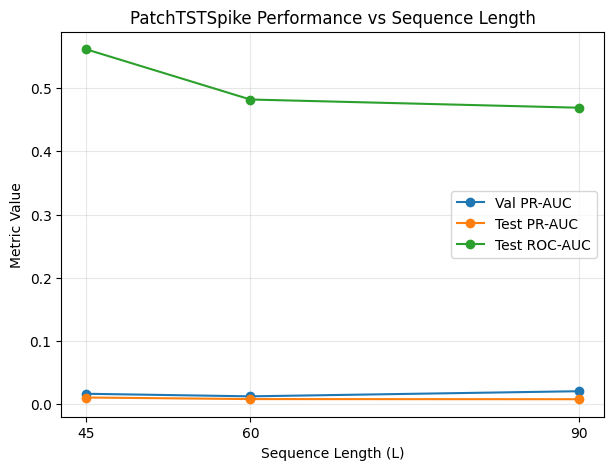

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(results_df["L"], results_df["Val_PR_AUC"], marker="o", label="Val PR-AUC")
plt.plot(results_df["L"], results_df["Test_PR_AUC"], marker="o", label="Test PR-AUC")
plt.plot(results_df["L"], results_df["Test_ROC_AUC"], marker="o", label="Test ROC-AUC")

plt.xlabel("Sequence Length (L)")
plt.ylabel("Metric Value")
plt.title("PatchTSTSpike Performance vs Sequence Length")
plt.xticks(results_df["L"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
print("Best by Test PR-AUC:")
print(results_df.sort_values("Test_PR_AUC", ascending=False)[["L", "Val_PR_AUC", "Test_PR_AUC", "Test_ROC_AUC", "Test_F1"]])

print("\nBest by Test ROC-AUC:")
print(results_df.sort_values("Test_ROC_AUC", ascending=False)[["L", "Val_PR_AUC", "Test_PR_AUC", "Test_ROC_AUC", "Test_F1"]])

Best by Test PR-AUC:
    L  Val_PR_AUC  Test_PR_AUC  Test_ROC_AUC   Test_F1
0  45    0.016749     0.010820      0.561495  0.027624
1  60    0.012656     0.008326      0.481989  0.021136
2  90    0.020774     0.008105      0.469010  0.017467

Best by Test ROC-AUC:
    L  Val_PR_AUC  Test_PR_AUC  Test_ROC_AUC   Test_F1
0  45    0.016749     0.010820      0.561495  0.027624
1  60    0.012656     0.008326      0.481989  0.021136
2  90    0.020774     0.008105      0.469010  0.017467


In [ ]:
# correlation analysis on TRAIN only
corr_cols = ["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region", "y"]

corr_mat = train_df[corr_cols].corr(method="pearson")
print(corr_mat.round(4))

                  tp_region_max_mm  t2m_region  r_region  u_region  \
tp_region_max_mm            1.0000      0.6047    0.5177   -0.5595   
t2m_region                  0.6047      1.0000    0.8291   -0.9095   
r_region                    0.5177      0.8291    1.0000   -0.7990   
u_region                   -0.5595     -0.9095   -0.7990    1.0000   
tcc_region                  0.4073      0.4717    0.3098   -0.3737   
y                           0.3111      0.0158    0.0063   -0.0127   

                  tcc_region       y  
tp_region_max_mm      0.4073  0.3111  
t2m_region            0.4717  0.0158  
r_region              0.3098  0.0063  
u_region             -0.3737 -0.0127  
tcc_region            1.0000  0.0530  
y                     0.0530  1.0000  


In [ ]:
# class-wise feature means on TRAIN
class_summary = train_df.groupby("y")[["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"]].mean()
print(class_summary.round(4))

   tp_region_max_mm  t2m_region  r_region  u_region  tcc_region
y                                                              
0          3.980200     -0.0017   -0.0007    0.0014     -0.0057
1         16.243299      0.1475    0.0587   -0.1184      0.4940


In [ ]:
# class-wise feature standard deviations on TRAIN
class_std = train_df.groupby("y")[["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"]].std()
print(class_std.round(4))

   tp_region_max_mm  t2m_region  r_region  u_region  tcc_region
y                                                              
0            3.9002      1.0010    0.9995    1.0006      0.9992
1            8.0864      0.9008    1.0424    0.9401      0.9481


In [ ]:
# standardized mean separation (Cohen-style effect size) on TRAIN
feature_list = ["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"]

rows = []
for col in feature_list:
    m0 = train_df.loc[train_df["y"] == 0, col].mean()
    m1 = train_df.loc[train_df["y"] == 1, col].mean()
    s0 = train_df.loc[train_df["y"] == 0, col].std()
    s1 = train_df.loc[train_df["y"] == 1, col].std()
    pooled = np.sqrt((s0**2 + s1**2) / 2.0)
    d = (m1 - m0) / (pooled + 1e-12)
    rows.append({"feature": col, "effect_size_d": d})

effect_df = pd.DataFrame(rows).sort_values("effect_size_d", ascending=False).reset_index(drop=True)
print(effect_df.round(4))

            feature  effect_size_d
0  tp_region_max_mm         1.9317
1        tcc_region         0.5131
2        t2m_region         0.1567
3          r_region         0.0582
4          u_region        -0.1234


In [ ]:
from sklearn.feature_selection import mutual_info_classif

feature_list = ["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"]

X_mi = train_df[feature_list].values
y_mi = train_df["y"].values.astype(int)

mi = mutual_info_classif(X_mi, y_mi, random_state=42)

mi_df = pd.DataFrame({
    "feature": feature_list,
    "mutual_info": mi
}).sort_values("mutual_info", ascending=False).reset_index(drop=True)

print(mi_df.round(6))

            feature  mutual_info
0  tp_region_max_mm     0.027244
1        tcc_region     0.001032
2        t2m_region     0.000389
3          r_region     0.000000
4          u_region     0.000000


In [ ]:
# combine correlation, effect size, and mutual information into one table
corr_with_y = train_df[["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region", "y"]].corr()["y"].drop("y")

feature_rank_df = pd.DataFrame({
    "feature": ["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"],
    "pearson_with_y": [corr_with_y[f] for f in ["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"]],
}).merge(effect_df, on="feature").merge(mi_df, on="feature")

feature_rank_df = feature_rank_df.sort_values(
    ["mutual_info", "effect_size_d", "pearson_with_y"],
    ascending=False
).reset_index(drop=True)

print(feature_rank_df.round(6))

            feature  pearson_with_y  effect_size_d  mutual_info
0  tp_region_max_mm        0.311118       1.931723     0.027244
1        tcc_region        0.052988       0.513079     0.001032
2        t2m_region        0.015824       0.156718     0.000389
3          r_region        0.006299       0.058178     0.000000
4          u_region       -0.012699      -0.123356     0.000000


In [ ]:
# save feature ranking table
feature_rank_df.to_csv("feature_ranking_train_spike_label.csv", index=False)
feature_rank_df

,feature,pearson_with_y,effect_size_d,mutual_info
0,tp_region_max_mm,0.311118,1.931723,0.027244
1,tcc_region,0.052988,0.513079,0.001032
2,t2m_region,0.015824,0.156718,0.000389
3,r_region,0.006299,0.058178,0.000000
4,u_region,-0.012699,-0.123356,0.000000


In [ ]:
# build compact paper summary table
mean_0 = train_df[train_df["y"] == 0][["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"]].mean()
mean_1 = train_df[train_df["y"] == 1][["tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region"]].mean()

paper_feature_summary = feature_rank_df.copy()
paper_feature_summary["mean_y0"] = paper_feature_summary["feature"].map(mean_0.to_dict())
paper_feature_summary["mean_y1"] = paper_feature_summary["feature"].map(mean_1.to_dict())
paper_feature_summary["mean_shift_y1_minus_y0"] = paper_feature_summary["mean_y1"] - paper_feature_summary["mean_y0"]

paper_feature_summary = paper_feature_summary[
    ["feature", "mean_y0", "mean_y1", "mean_shift_y1_minus_y0", "pearson_with_y", "effect_size_d", "mutual_info"]
]

print(paper_feature_summary.round(6))

            feature   mean_y0    mean_y1  mean_shift_y1_minus_y0  \
0  tp_region_max_mm  3.980194  16.243309               12.263115   
1        tcc_region -0.005683   0.494044                0.499728   
2        t2m_region -0.001697   0.147536                0.149234   
3          r_region -0.000676   0.058734                0.059410   
4          u_region  0.001362  -0.118399               -0.119761   

   pearson_with_y  effect_size_d  mutual_info  
0        0.311118       1.931723     0.027244  
1        0.052988       0.513079     0.001032  
2        0.015824       0.156718     0.000389  
3        0.006299       0.058178     0.000000  
4       -0.012699      -0.123356     0.000000  


In [ ]:
# save final paper feature summary table
paper_feature_summary.to_csv("paper_feature_summary_train_spike.csv", index=False)
paper_feature_summary

,feature,mean_y0,mean_y1,mean_shift_y1_minus_y0,pearson_with_y,effect_size_d,mutual_info
0,tp_region_max_mm,3.980194,16.243309,12.263115,0.311118,1.931723,0.027244
1,tcc_region,-0.005683,0.494044,0.499728,0.052988,0.513079,0.001032
2,t2m_region,-0.001697,0.147536,0.149234,0.015824,0.156718,0.000389
3,r_region,-0.000676,0.058734,0.059410,0.006299,0.058178,0.000000
4,u_region,0.001362,-0.118399,-0.119761,-0.012699,-0.123356,0.000000


In [ ]:
print("Current feature_cols:", feature_cols)

intended_feature_cols = ["tp_region_mean_mm", "t2m_region", "r_region", "u_region", "tcc_region"]
print("Intended feature_cols:", intended_feature_cols)

print("\nDo they match?", feature_cols == intended_feature_cols)

Current feature_cols: ['tp_region_max_mm', 't2m_region', 'r_region', 'u_region', 'tcc_region']
Intended feature_cols: ['tp_region_mean_mm', 't2m_region', 'r_region', 'u_region', 'tcc_region']

Do they match? False


In [ ]:
# check that the intended rainfall feature exists in all splits
cols_to_check = ["tp_region_mean_mm", "tp_region_max_mm", "t2m_region", "r_region", "u_region", "tcc_region", "y"]

print("train_df columns present:")
print({c: (c in train_df.columns) for c in cols_to_check})

print("\nval_df columns present:")
print({c: (c in val_df.columns) for c in cols_to_check})

print("\ntest_df columns present:")
print({c: (c in test_df.columns) for c in cols_to_check})

train_df columns present:
{'tp_region_mean_mm': True, 'tp_region_max_mm': True, 't2m_region': True, 'r_region': True, 'u_region': True, 'tcc_region': True, 'y': True}

val_df columns present:
{'tp_region_mean_mm': True, 'tp_region_max_mm': True, 't2m_region': True, 'r_region': True, 'u_region': True, 'tcc_region': True, 'y': True}

test_df columns present:
{'tp_region_mean_mm': True, 'tp_region_max_mm': True, 't2m_region': True, 'r_region': True, 'u_region': True, 'tcc_region': True, 'y': True}


In [ ]:
# fix feature set to avoid target leakage
feature_cols = ["tp_region_mean_mm", "t2m_region", "r_region", "u_region", "tcc_region"]
target_col = "y"

print("Updated feature_cols:", feature_cols)
print("Number of features:", len(feature_cols))

Updated feature_cols: ['tp_region_mean_mm', 't2m_region', 'r_region', 'u_region', 'tcc_region']
Number of features: 5


In [ ]:
# recompute feature relevance table for the corrected, non-leaky feature set
from sklearn.feature_selection import mutual_info_classif

feature_list = ["tp_region_mean_mm", "t2m_region", "r_region", "u_region", "tcc_region"]

# Pearson with y
corr_with_y = train_df[feature_list + ["y"]].corr(method="pearson")["y"].drop("y")

# Effect size
rows = []
for col in feature_list:
    m0 = train_df.loc[train_df["y"] == 0, col].mean()
    m1 = train_df.loc[train_df["y"] == 1, col].mean()
    s0 = train_df.loc[train_df["y"] == 0, col].std()
    s1 = train_df.loc[train_df["y"] == 1, col].std()
    pooled = np.sqrt((s0**2 + s1**2) / 2.0)
    d = (m1 - m0) / (pooled + 1e-12)
    rows.append({"feature": col, "effect_size_d": d})
effect_df_fixed = pd.DataFrame(rows)

# Mutual information
X_mi = train_df[feature_list].values
y_mi = train_df["y"].values.astype(int)
mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df_fixed = pd.DataFrame({
    "feature": feature_list,
    "mutual_info": mi
})

# Combine
feature_rank_df_fixed = pd.DataFrame({
    "feature": feature_list,
    "pearson_with_y": [corr_with_y[f] for f in feature_list],
}).merge(effect_df_fixed, on="feature").merge(mi_df_fixed, on="feature")

feature_rank_df_fixed = feature_rank_df_fixed.sort_values(
    ["mutual_info", "effect_size_d", "pearson_with_y"],
    ascending=False
).reset_index(drop=True)

print(feature_rank_df_fixed.round(6))

             feature  pearson_with_y  effect_size_d  mutual_info
0  tp_region_mean_mm        0.225925       1.543890     0.015254
1         tcc_region        0.052988       0.513079     0.001032
2         t2m_region        0.015824       0.156718     0.000389
3           r_region        0.006299       0.058178     0.000000
4           u_region       -0.012699      -0.123356     0.000000


In [ ]:
# corrected paper summary table for the non-leaky feature set
mean_0_fixed = train_df[train_df["y"] == 0][["tp_region_mean_mm", "t2m_region", "r_region", "u_region", "tcc_region"]].mean()
mean_1_fixed = train_df[train_df["y"] == 1][["tp_region_mean_mm", "t2m_region", "r_region", "u_region", "tcc_region"]].mean()

paper_feature_summary_fixed = feature_rank_df_fixed.copy()
paper_feature_summary_fixed["mean_y0"] = paper_feature_summary_fixed["feature"].map(mean_0_fixed.to_dict())
paper_feature_summary_fixed["mean_y1"] = paper_feature_summary_fixed["feature"].map(mean_1_fixed.to_dict())
paper_feature_summary_fixed["mean_shift_y1_minus_y0"] = (
    paper_feature_summary_fixed["mean_y1"] - paper_feature_summary_fixed["mean_y0"]
)

paper_feature_summary_fixed = paper_feature_summary_fixed[
    ["feature", "mean_y0", "mean_y1", "mean_shift_y1_minus_y0", "pearson_with_y", "effect_size_d", "mutual_info"]
]

print(paper_feature_summary_fixed.round(6))

             feature   mean_y0   mean_y1  mean_shift_y1_minus_y0  \
0  tp_region_mean_mm -0.024231  2.106459                2.130690   
1         tcc_region -0.005683  0.494044                0.499728   
2         t2m_region -0.001697  0.147536                0.149234   
3           r_region -0.000676  0.058734                0.059410   
4           u_region  0.001362 -0.118399               -0.119761   

   pearson_with_y  effect_size_d  mutual_info  
0        0.225925       1.543890     0.015254  
1        0.052988       0.513079     0.001032  
2        0.015824       0.156718     0.000389  
3        0.006299       0.058178     0.000000  
4       -0.012699      -0.123356     0.000000  


In [ ]:
# save corrected non-leaky feature tables
feature_rank_df_fixed.to_csv("feature_ranking_train_spike_label_nonleaky.csv", index=False)
paper_feature_summary_fixed.to_csv("paper_feature_summary_train_spike_nonleaky.csv", index=False)

print("Saved:")
print("- feature_ranking_train_spike_label_nonleaky.csv")
print("- paper_feature_summary_train_spike_nonleaky.csv")

Saved:
- feature_ranking_train_spike_label_nonleaky.csv
- paper_feature_summary_train_spike_nonleaky.csv


In [ ]:
from torch.utils.data import DataLoader

feature_cols = ["tp_region_mean_mm", "t2m_region", "r_region", "u_region", "tcc_region"]
target_col = "y"
L = 30
batch_size = 256

train_ds_30 = SequenceDataset(train_df, feature_cols, target_col, seq_len=L)
val_ds_30   = SequenceDataset(val_df,   feature_cols, target_col, seq_len=L)
test_ds_30  = SequenceDataset(test_df,  feature_cols, target_col, seq_len=L)

train_loader_30 = DataLoader(train_ds_30, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_30   = DataLoader(val_ds_30,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_30  = DataLoader(test_ds_30,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

x0, y0 = train_ds_30[0]
print("L=30 sample x shape:", x0.shape)
print("L=30 sizes:", len(train_ds_30), len(val_ds_30), len(test_ds_30))
print("Using feature_cols:", feature_cols)

L=30 sample x shape: torch.Size([30, 5])
L=30 sizes: 16589 3531 3532
Using feature_cols: ['tp_region_mean_mm', 't2m_region', 'r_region', 'u_region', 'tcc_region']


In [ ]:
# build fresh non-leaky L=30 model
model_30 = PatchTSTSpike(
    seq_len=30,
    patch_len=5,
    in_dim=len(feature_cols),
    d_model=256,
    n_heads=8,
    n_layers=4,
    d_ff=1024,
    dropout=0.1
).to(device)

print(model_30.__class__.__name__)
print("L=30 model created on:", device)
print("Total parameters:", sum(p.numel() for p in model_30.parameters()))

PatchTSTSpike
L=30 model created on: cuda
Total parameters: 3168513


/tmp/ipykernel_926/625831165.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [ ]:
# recreate SAM optimizer on current non-leaky model_30
base_optimizer = torch.optim.AdamW
optimizer_30_sam = SAM(
    model_30.parameters(),
    base_optimizer,
    lr=1e-4,
    weight_decay=1e-4
)

print("optimizer_30_sam ready")

optimizer_30_sam ready


In [ ]:
best_pr_30 = -1.0
best_state_30 = None
best_epoch_30 = -1
history_30 = []

EPOCHS = 20
for ep in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_sam(model_30, train_loader_30, optimizer_30_sam, criterion_focal, grad_clip=1.0)
    val_metrics_30 = eval_val(model_30, val_loader_30)

    history_30.append({
        "epoch": ep,
        "train_loss": train_loss,
        "roc_auc": val_metrics_30["roc_auc"],
        "pr_auc": val_metrics_30["pr_auc"],
        "best_th": val_metrics_30["best_th"],
        "f1": val_metrics_30["f1"],
        "precision": val_metrics_30["precision"],
        "recall": val_metrics_30["recall"],
    })

    print(
        f"[L=30 SAM | non-leaky] Epoch {ep:02d} | loss {train_loss:.4f} | PR {val_metrics_30['pr_auc']:.5f} | "
        f"ROC {val_metrics_30['roc_auc']:.4f} | F1 {val_metrics_30['f1']:.4f} | "
        f"Prec {val_metrics_30['precision']:.4f} | Rec {val_metrics_30['recall']:.4f} | th {val_metrics_30['best_th']:.2f}"
    )

    if val_metrics_30["pr_auc"] > best_pr_30:
        best_pr_30 = val_metrics_30["pr_auc"]
        best_epoch_30 = ep
        best_state_30 = {k: v.detach().cpu().clone() for k, v in model_30.state_dict().items()}
        print("  ✅ New best PR-AUC saved:", best_pr_30, "at epoch", best_epoch_30)

if best_state_30 is not None:
    model_30.load_state_dict(best_state_30, strict=True)
    print("✅ Restored best non-leaky L=30 model by PR-AUC:", best_pr_30, "from epoch", best_epoch_30)

[L=30 SAM | non-leaky] Epoch 01 | loss 0.3740 | PR 0.01213 | ROC 0.5555 | F1 0.0303 | Prec 0.0256 | Rec 0.0370 | th 0.81
  ✅ New best PR-AUC saved: 0.012132686397513043 at epoch 1
[L=30 SAM | non-leaky] Epoch 02 | loss 0.3506 | PR 0.01092 | ROC 0.5723 | F1 0.0271 | Prec 0.0149 | Rec 0.1481 | th 0.87
[L=30 SAM | non-leaky] Epoch 03 | loss 0.3454 | PR 0.01202 | ROC 0.6258 | F1 0.0287 | Prec 0.0156 | Rec 0.1852 | th 0.84
[L=30 SAM | non-leaky] Epoch 04 | loss 0.3340 | PR 0.01061 | ROC 0.6068 | F1 0.0244 | Prec 0.0137 | Rec 0.1111 | th 0.88
[L=30 SAM | non-leaky] Epoch 05 | loss 0.3273 | PR 0.01171 | ROC 0.6018 | F1 0.0280 | Prec 0.0160 | Rec 0.1111 | th 0.86
[L=30 SAM | non-leaky] Epoch 06 | loss 0.3244 | PR 0.00980 | ROC 0.5884 | F1 0.0203 | Prec 0.0107 | Rec 0.1852 | th 0.86
[L=30 SAM | non-leaky] Epoch 07 | loss 0.3259 | PR 0.01298 | ROC 0.6273 | F1 0.0364 | Prec 0.0202 | Rec 0.1852 | th 0.91
  ✅ New best PR-AUC saved: 0.012978794041460717 at epoch 7
[L=30 SAM | non-leaky] Epoch 08 | l

In [ ]:
# test non-leaky L=30
test_metrics_30 = eval_val(model_30, test_loader_30)
print("L=30 TEST ROC-AUC:", test_metrics_30["roc_auc"])
print("L=30 TEST PR-AUC:", test_metrics_30["pr_auc"])
print("L=30 TEST best_th:", test_metrics_30["best_th"])
print("L=30 TEST F1:", test_metrics_30["f1"])
print("L=30 TEST Precision:", test_metrics_30["precision"])
print("L=30 TEST Recall:", test_metrics_30["recall"])

L=30 TEST ROC-AUC: 0.6007329145250333
L=30 TEST PR-AUC: 0.01622582591117444
L=30 TEST best_th: 0.8200000000000001
L=30 TEST F1: 0.041884816753926704
L=30 TEST Precision: 0.022099447513812154
L=30 TEST Recall: 0.4


In [ ]:
# start clean non-leaky results table
results_rows_nonleaky = [{
    "L": 30,
    "Val_PR_AUC": best_pr_30,
    "Test_ROC_AUC": test_metrics_30["roc_auc"],
    "Test_PR_AUC": test_metrics_30["pr_auc"],
    "Test_F1": test_metrics_30["f1"],
    "Test_Precision": test_metrics_30["precision"],
    "Test_Recall": test_metrics_30["recall"],
    "Best_Threshold": test_metrics_30["best_th"],
    "Best_Epoch": best_epoch_30,
}]

results_df_nonleaky = pd.DataFrame(results_rows_nonleaky)
results_df_nonleaky

,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch
0,30,0.015253,0.600733,0.016226,0.041885,0.022099,0.4,0.82,20


In [ ]:
from torch.utils.data import DataLoader

feature_cols = ["tp_region_mean_mm", "t2m_region", "r_region", "u_region", "tcc_region"]
target_col = "y"
L = 45
batch_size = 256

train_ds_45 = SequenceDataset(train_df, feature_cols, target_col, seq_len=L)
val_ds_45   = SequenceDataset(val_df,   feature_cols, target_col, seq_len=L)
test_ds_45  = SequenceDataset(test_df,  feature_cols, target_col, seq_len=L)

train_loader_45 = DataLoader(train_ds_45, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_45   = DataLoader(val_ds_45,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_45  = DataLoader(test_ds_45,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

x0, y0 = train_ds_45[0]
print("L=45 sample x shape:", x0.shape)
print("L=45 sizes:", len(train_ds_45), len(val_ds_45), len(test_ds_45))
print("Using feature_cols:", feature_cols)

L=45 sample x shape: torch.Size([45, 5])
L=45 sizes: 16574 3516 3517
Using feature_cols: ['tp_region_mean_mm', 't2m_region', 'r_region', 'u_region', 'tcc_region']


In [ ]:
# build fresh non-leaky L=45 model
model_45 = PatchTSTSpike(
    seq_len=45,
    patch_len=5,
    in_dim=len(feature_cols),
    d_model=256,
    n_heads=8,
    n_layers=4,
    d_ff=1024,
    dropout=0.1
).to(device)

print(model_45.__class__.__name__)
print("L=45 model created on:", device)
print("Total parameters:", sum(p.numel() for p in model_45.parameters()))

PatchTSTSpike
L=45 model created on: cuda
Total parameters: 3169281


/tmp/ipykernel_926/625831165.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [ ]:
# load compatible weights from non-leaky L=30 -> L=45, skip shape-mismatch keys like pos_embed
state_30 = model_30.state_dict()
state_45 = model_45.state_dict()

loaded_keys = []
skipped_keys = []

for k, v in state_30.items():
    if k in state_45 and state_45[k].shape == v.shape:
        state_45[k] = v
        loaded_keys.append(k)
    else:
        skipped_keys.append(k)

model_45.load_state_dict(state_45, strict=False)

print("Loaded keys:", len(loaded_keys))
print("Skipped keys:", skipped_keys)

Loaded keys: 55
Skipped keys: ['pos_embed']


In [ ]:
# recreate SAM optimizer on current non-leaky model_45
base_optimizer = torch.optim.AdamW
optimizer_45_sam = SAM(
    model_45.parameters(),
    base_optimizer,
    lr=1e-4,
    weight_decay=1e-4
)

print("optimizer_45_sam ready")

optimizer_45_sam ready


In [ ]:
best_pr_45 = -1.0
best_state_45 = None
best_epoch_45 = -1
history_45 = []

EPOCHS = 20
for ep in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_sam(model_45, train_loader_45, optimizer_45_sam, criterion_focal, grad_clip=1.0)
    val_metrics_45 = eval_val(model_45, val_loader_45)

    history_45.append({
        "epoch": ep,
        "train_loss": train_loss,
        "roc_auc": val_metrics_45["roc_auc"],
        "pr_auc": val_metrics_45["pr_auc"],
        "best_th": val_metrics_45["best_th"],
        "f1": val_metrics_45["f1"],
        "precision": val_metrics_45["precision"],
        "recall": val_metrics_45["recall"],
    })

    print(
        f"[L=45 SAM | non-leaky] Epoch {ep:02d} | loss {train_loss:.4f} | PR {val_metrics_45['pr_auc']:.5f} | "
        f"ROC {val_metrics_45['roc_auc']:.4f} | F1 {val_metrics_45['f1']:.4f} | "
        f"Prec {val_metrics_45['precision']:.4f} | Rec {val_metrics_45['recall']:.4f} | th {val_metrics_45['best_th']:.2f}"
    )

    if val_metrics_45["pr_auc"] > best_pr_45:
        best_pr_45 = val_metrics_45["pr_auc"]
        best_epoch_45 = ep
        best_state_45 = {k: v.detach().cpu().clone() for k, v in model_45.state_dict().items()}
        print("  ✅ New best PR-AUC saved:", best_pr_45, "at epoch", best_epoch_45)

if best_state_45 is not None:
    model_45.load_state_dict(best_state_45, strict=True)
    print("✅ Restored best non-leaky L=45 model by PR-AUC:", best_pr_45, "from epoch", best_epoch_45)

[L=45 SAM | non-leaky] Epoch 01 | loss 0.2908 | PR 0.01073 | ROC 0.5505 | F1 0.0339 | Prec 0.0312 | Rec 0.0370 | th 0.90
  ✅ New best PR-AUC saved: 0.010728071087859375 at epoch 1
[L=45 SAM | non-leaky] Epoch 02 | loss 0.2668 | PR 0.01568 | ROC 0.6304 | F1 0.0417 | Prec 0.0256 | Rec 0.1111 | th 0.96
  ✅ New best PR-AUC saved: 0.01567959395845115 at epoch 2
[L=45 SAM | non-leaky] Epoch 03 | loss 0.2452 | PR 0.01936 | ROC 0.6507 | F1 0.0482 | Prec 0.0357 | Rec 0.0741 | th 0.94
  ✅ New best PR-AUC saved: 0.019359002949511275 at epoch 3
[L=45 SAM | non-leaky] Epoch 04 | loss 0.2309 | PR 0.01997 | ROC 0.6501 | F1 0.0571 | Prec 0.0465 | Rec 0.0741 | th 0.98
  ✅ New best PR-AUC saved: 0.019966266854338992 at epoch 4
[L=45 SAM | non-leaky] Epoch 05 | loss 0.2215 | PR 0.01874 | ROC 0.6575 | F1 0.0423 | Prec 0.0261 | Rec 0.1111 | th 0.96
[L=45 SAM | non-leaky] Epoch 06 | loss 0.2175 | PR 0.05986 | ROC 0.6695 | F1 0.0741 | Prec 0.0741 | Rec 0.0741 | th 0.98
  ✅ New best PR-AUC saved: 0.0598584530

In [ ]:
# test non-leaky L=45
test_metrics_45 = eval_val(model_45, test_loader_45)
print("L=45 TEST ROC-AUC:", test_metrics_45["roc_auc"])
print("L=45 TEST PR-AUC:", test_metrics_45["pr_auc"])
print("L=45 TEST best_th:", test_metrics_45["best_th"])
print("L=45 TEST F1:", test_metrics_45["f1"])
print("L=45 TEST Precision:", test_metrics_45["precision"])
print("L=45 TEST Recall:", test_metrics_45["recall"])

L=45 TEST ROC-AUC: 0.5496702036134213
L=45 TEST PR-AUC: 0.012179171845163725
L=45 TEST best_th: 0.93
L=45 TEST F1: 0.037037037037037035
L=45 TEST Precision: 0.022727272727272728
L=45 TEST Recall: 0.1


In [ ]:
# append non-leaky L=45 result
results_rows_nonleaky.append({
    "L": 45,
    "Val_PR_AUC": best_pr_45,
    "Test_ROC_AUC": test_metrics_45["roc_auc"],
    "Test_PR_AUC": test_metrics_45["pr_auc"],
    "Test_F1": test_metrics_45["f1"],
    "Test_Precision": test_metrics_45["precision"],
    "Test_Recall": test_metrics_45["recall"],
    "Best_Threshold": test_metrics_45["best_th"],
    "Best_Epoch": best_epoch_45,
})

results_df_nonleaky = pd.DataFrame(results_rows_nonleaky).sort_values("L").reset_index(drop=True)
results_df_nonleaky

,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch
0,30,0.015253,0.600733,0.016226,0.041885,0.022099,0.4,0.82,20
1,45,0.059858,0.549670,0.012179,0.037037,0.022727,0.1,0.93,6


In [ ]:
from torch.utils.data import DataLoader

feature_cols = ["tp_region_mean_mm", "t2m_region", "r_region", "u_region", "tcc_region"]
target_col = "y"
L = 60
batch_size = 256

train_ds_60 = SequenceDataset(train_df, feature_cols, target_col, seq_len=L)
val_ds_60   = SequenceDataset(val_df,   feature_cols, target_col, seq_len=L)
test_ds_60  = SequenceDataset(test_df,  feature_cols, target_col, seq_len=L)

train_loader_60 = DataLoader(train_ds_60, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_60   = DataLoader(val_ds_60,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_60  = DataLoader(test_ds_60,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

x0, y0 = train_ds_60[0]
print("L=60 sample x shape:", x0.shape)
print("L=60 sizes:", len(train_ds_60), len(val_ds_60), len(test_ds_60))
print("Using feature_cols:", feature_cols)

L=60 sample x shape: torch.Size([60, 5])
L=60 sizes: 16559 3501 3502
Using feature_cols: ['tp_region_mean_mm', 't2m_region', 'r_region', 'u_region', 'tcc_region']


In [ ]:
# build fresh non-leaky L=60 model
model_60 = PatchTSTSpike(
    seq_len=60,
    patch_len=5,
    in_dim=len(feature_cols),
    d_model=256,
    n_heads=8,
    n_layers=4,
    d_ff=1024,
    dropout=0.1
).to(device)

print(model_60.__class__.__name__)
print("L=60 model created on:", device)
print("Total parameters:", sum(p.numel() for p in model_60.parameters()))

PatchTSTSpike
L=60 model created on: cuda
Total parameters: 3170049


/tmp/ipykernel_926/625831165.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [ ]:
# load compatible weights from non-leaky L=45 -> L=60, skip shape-mismatch keys like pos_embed
state_45 = model_45.state_dict()
state_60 = model_60.state_dict()

loaded_keys = []
skipped_keys = []

for k, v in state_45.items():
    if k in state_60 and state_60[k].shape == v.shape:
        state_60[k] = v
        loaded_keys.append(k)
    else:
        skipped_keys.append(k)

model_60.load_state_dict(state_60, strict=False)

print("Loaded keys:", len(loaded_keys))
print("Skipped keys:", skipped_keys)

Loaded keys: 55
Skipped keys: ['pos_embed']


In [ ]:
# recreate SAM optimizer on current non-leaky model_60
base_optimizer = torch.optim.AdamW
optimizer_60_sam = SAM(
    model_60.parameters(),
    base_optimizer,
    lr=1e-4,
    weight_decay=1e-4
)

print("optimizer_60_sam ready")

optimizer_60_sam ready


In [ ]:
best_pr_60 = -1.0
best_state_60 = None
best_epoch_60 = -1
history_60 = []

EPOCHS = 20
for ep in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_sam(model_60, train_loader_60, optimizer_60_sam, criterion_focal, grad_clip=1.0)
    val_metrics_60 = eval_val(model_60, val_loader_60)

    history_60.append({
        "epoch": ep,
        "train_loss": train_loss,
        "roc_auc": val_metrics_60["roc_auc"],
        "pr_auc": val_metrics_60["pr_auc"],
        "best_th": val_metrics_60["best_th"],
        "f1": val_metrics_60["f1"],
        "precision": val_metrics_60["precision"],
        "recall": val_metrics_60["recall"],
    })

    print(
        f"[L=60 SAM | non-leaky] Epoch {ep:02d} | loss {train_loss:.4f} | PR {val_metrics_60['pr_auc']:.5f} | "
        f"ROC {val_metrics_60['roc_auc']:.4f} | F1 {val_metrics_60['f1']:.4f} | "
        f"Prec {val_metrics_60['precision']:.4f} | Rec {val_metrics_60['recall']:.4f} | th {val_metrics_60['best_th']:.2f}"
    )

    if val_metrics_60["pr_auc"] > best_pr_60:
        best_pr_60 = val_metrics_60["pr_auc"]
        best_epoch_60 = ep
        best_state_60 = {k: v.detach().cpu().clone() for k, v in model_60.state_dict().items()}
        print("  ✅ New best PR-AUC saved:", best_pr_60, "at epoch", best_epoch_60)

if best_state_60 is not None:
    model_60.load_state_dict(best_state_60, strict=True)
    print("✅ Restored best non-leaky L=60 model by PR-AUC:", best_pr_60, "from epoch", best_epoch_60)

[L=60 SAM | non-leaky] Epoch 01 | loss 0.2762 | PR 0.01190 | ROC 0.6133 | F1 0.0345 | Prec 0.0181 | Rec 0.3704 | th 0.87
  ✅ New best PR-AUC saved: 0.011904465667264975 at epoch 1
[L=60 SAM | non-leaky] Epoch 02 | loss 0.2328 | PR 0.02078 | ROC 0.6105 | F1 0.0476 | Prec 0.0667 | Rec 0.0370 | th 0.98
  ✅ New best PR-AUC saved: 0.020778903524357597 at epoch 2
[L=60 SAM | non-leaky] Epoch 03 | loss 0.2244 | PR 0.01422 | ROC 0.5904 | F1 0.0426 | Prec 0.0500 | Rec 0.0370 | th 0.97
[L=60 SAM | non-leaky] Epoch 04 | loss 0.2067 | PR 0.01661 | ROC 0.6222 | F1 0.0580 | Prec 0.0476 | Rec 0.0741 | th 0.97
[L=60 SAM | non-leaky] Epoch 05 | loss 0.1909 | PR 0.02164 | ROC 0.6333 | F1 0.0500 | Prec 0.0377 | Rec 0.0741 | th 0.98
  ✅ New best PR-AUC saved: 0.021637878568166145 at epoch 5
[L=60 SAM | non-leaky] Epoch 06 | loss 0.1675 | PR 0.02082 | ROC 0.6184 | F1 0.0625 | Prec 0.2000 | Rec 0.0370 | th 0.98
[L=60 SAM | non-leaky] Epoch 07 | loss 0.1664 | PR 0.01670 | ROC 0.6288 | F1 0.0408 | Prec 0.0225

In [ ]:
# test non-leaky L=60
test_metrics_60 = eval_val(model_60, test_loader_60)
print("L=60 TEST ROC-AUC:", test_metrics_60["roc_auc"])
print("L=60 TEST PR-AUC:", test_metrics_60["pr_auc"])
print("L=60 TEST best_th:", test_metrics_60["best_th"])
print("L=60 TEST F1:", test_metrics_60["f1"])
print("L=60 TEST Precision:", test_metrics_60["precision"])
print("L=60 TEST Recall:", test_metrics_60["recall"])

L=60 TEST ROC-AUC: 0.5448636712749616
L=60 TEST PR-AUC: 0.01535455684183402
L=60 TEST best_th: 0.99
L=60 TEST F1: 0.047619047619047616
L=60 TEST Precision: 0.08333333333333333
L=60 TEST Recall: 0.03333333333333333


In [ ]:
# append non-leaky L=60 result
results_rows_nonleaky.append({
    "L": 60,
    "Val_PR_AUC": best_pr_60,
    "Test_ROC_AUC": test_metrics_60["roc_auc"],
    "Test_PR_AUC": test_metrics_60["pr_auc"],
    "Test_F1": test_metrics_60["f1"],
    "Test_Precision": test_metrics_60["precision"],
    "Test_Recall": test_metrics_60["recall"],
    "Best_Threshold": test_metrics_60["best_th"],
    "Best_Epoch": best_epoch_60,
})

results_df_nonleaky = pd.DataFrame(results_rows_nonleaky).sort_values("L").reset_index(drop=True)
results_df_nonleaky

,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch
0,30,0.015253,0.600733,0.016226,0.041885,0.022099,0.400000,0.82,20
1,45,0.059858,0.549670,0.012179,0.037037,0.022727,0.100000,0.93,6
2,60,0.021638,0.544864,0.015355,0.047619,0.083333,0.033333,0.99,5


In [ ]:
from torch.utils.data import DataLoader

feature_cols = ["tp_region_mean_mm", "t2m_region", "r_region", "u_region", "tcc_region"]
target_col = "y"
L = 90
batch_size = 256

train_ds_90 = SequenceDataset(train_df, feature_cols, target_col, seq_len=L)
val_ds_90   = SequenceDataset(val_df,   feature_cols, target_col, seq_len=L)
test_ds_90  = SequenceDataset(test_df,  feature_cols, target_col, seq_len=L)

train_loader_90 = DataLoader(train_ds_90, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_90   = DataLoader(val_ds_90,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_90  = DataLoader(test_ds_90,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

x0, y0 = train_ds_90[0]
print("L=90 sample x shape:", x0.shape)
print("L=90 sizes:", len(train_ds_90), len(val_ds_90), len(test_ds_90))
print("Using feature_cols:", feature_cols)

L=90 sample x shape: torch.Size([90, 5])
L=90 sizes: 16529 3471 3472
Using feature_cols: ['tp_region_mean_mm', 't2m_region', 'r_region', 'u_region', 'tcc_region']


In [ ]:
# build fresh non-leaky L=90 model
model_90 = PatchTSTSpike(
    seq_len=90,
    patch_len=5,
    in_dim=len(feature_cols),
    d_model=256,
    n_heads=8,
    n_layers=4,
    d_ff=1024,
    dropout=0.1
).to(device)

print(model_90.__class__.__name__)
print("L=90 model created on:", device)
print("Total parameters:", sum(p.numel() for p in model_90.parameters()))

PatchTSTSpike
L=90 model created on: cuda
Total parameters: 3171585


/tmp/ipykernel_926/625831165.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [ ]:
# load compatible weights from non-leaky L=60 -> L=90, skip shape-mismatch keys like pos_embed
state_60 = model_60.state_dict()
state_90 = model_90.state_dict()

loaded_keys = []
skipped_keys = []

for k, v in state_60.items():
    if k in state_90 and state_90[k].shape == v.shape:
        state_90[k] = v
        loaded_keys.append(k)
    else:
        skipped_keys.append(k)

model_90.load_state_dict(state_90, strict=False)

print("Loaded keys:", len(loaded_keys))
print("Skipped keys:", skipped_keys)

Loaded keys: 55
Skipped keys: ['pos_embed']


In [ ]:
# recreate SAM optimizer on current non-leaky model_90
base_optimizer = torch.optim.AdamW
optimizer_90_sam = SAM(
    model_90.parameters(),
    base_optimizer,
    lr=1e-4,
    weight_decay=1e-4
)

print("optimizer_90_sam ready")

optimizer_90_sam ready


In [ ]:
best_pr_90 = -1.0
best_state_90 = None
best_epoch_90 = -1
history_90 = []

EPOCHS = 20
for ep in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_sam(model_90, train_loader_90, optimizer_90_sam, criterion_focal, grad_clip=1.0)
    val_metrics_90 = eval_val(model_90, val_loader_90)

    history_90.append({
        "epoch": ep,
        "train_loss": train_loss,
        "roc_auc": val_metrics_90["roc_auc"],
        "pr_auc": val_metrics_90["pr_auc"],
        "best_th": val_metrics_90["best_th"],
        "f1": val_metrics_90["f1"],
        "precision": val_metrics_90["precision"],
        "recall": val_metrics_90["recall"],
    })

    print(
        f"[L=90 SAM | non-leaky] Epoch {ep:02d} | loss {train_loss:.4f} | PR {val_metrics_90['pr_auc']:.5f} | "
        f"ROC {val_metrics_90['roc_auc']:.4f} | F1 {val_metrics_90['f1']:.4f} | "
        f"Prec {val_metrics_90['precision']:.4f} | Rec {val_metrics_90['recall']:.4f} | th {val_metrics_90['best_th']:.2f}"
    )

    if val_metrics_90["pr_auc"] > best_pr_90:
        best_pr_90 = val_metrics_90["pr_auc"]
        best_epoch_90 = ep
        best_state_90 = {k: v.detach().cpu().clone() for k, v in model_90.state_dict().items()}
        print("  ✅ New best PR-AUC saved:", best_pr_90, "at epoch", best_epoch_90)

if best_state_90 is not None:
    model_90.load_state_dict(best_state_90, strict=True)
    print("✅ Restored best non-leaky L=90 model by PR-AUC:", best_pr_90, "from epoch", best_epoch_90)

[L=90 SAM | non-leaky] Epoch 01 | loss 0.2378 | PR 0.01524 | ROC 0.6274 | F1 0.0556 | Prec 0.0444 | Rec 0.0741 | th 0.96
  ✅ New best PR-AUC saved: 0.01524352428441485 at epoch 1
[L=90 SAM | non-leaky] Epoch 02 | loss 0.2147 | PR 0.01779 | ROC 0.6338 | F1 0.0597 | Prec 0.0500 | Rec 0.0741 | th 0.97
  ✅ New best PR-AUC saved: 0.01778638345338116 at epoch 2
[L=90 SAM | non-leaky] Epoch 03 | loss 0.1964 | PR 0.01746 | ROC 0.6346 | F1 0.0645 | Prec 0.0571 | Rec 0.0741 | th 0.97
[L=90 SAM | non-leaky] Epoch 04 | loss 0.1726 | PR 0.01746 | ROC 0.6513 | F1 0.0513 | Prec 0.0333 | Rec 0.1111 | th 0.92
[L=90 SAM | non-leaky] Epoch 05 | loss 0.1720 | PR 0.01915 | ROC 0.6455 | F1 0.0470 | Prec 0.0253 | Rec 0.3333 | th 0.88
  ✅ New best PR-AUC saved: 0.019150062834328643 at epoch 5
[L=90 SAM | non-leaky] Epoch 06 | loss 0.1533 | PR 0.01488 | ROC 0.6330 | F1 0.0385 | Prec 0.0221 | Rec 0.1481 | th 0.96
[L=90 SAM | non-leaky] Epoch 07 | loss 0.1495 | PR 0.01785 | ROC 0.6499 | F1 0.0556 | Prec 0.0444 |

In [ ]:
# test non-leaky L=90
test_metrics_90 = eval_val(model_90, test_loader_90)
print("L=90 TEST ROC-AUC:", test_metrics_90["roc_auc"])
print("L=90 TEST PR-AUC:", test_metrics_90["pr_auc"])
print("L=90 TEST best_th:", test_metrics_90["best_th"])
print("L=90 TEST F1:", test_metrics_90["f1"])
print("L=90 TEST Precision:", test_metrics_90["precision"])
print("L=90 TEST Recall:", test_metrics_90["recall"])

L=90 TEST ROC-AUC: 0.576554328878559
L=90 TEST PR-AUC: 0.01256991911360213
L=90 TEST best_th: 0.88
L=90 TEST F1: 0.031914893617021274
L=90 TEST Precision: 0.017341040462427744
L=90 TEST Recall: 0.2


In [ ]:
# append non-leaky L=90 result
results_rows_nonleaky.append({
    "L": 90,
    "Val_PR_AUC": best_pr_90,
    "Test_ROC_AUC": test_metrics_90["roc_auc"],
    "Test_PR_AUC": test_metrics_90["pr_auc"],
    "Test_F1": test_metrics_90["f1"],
    "Test_Precision": test_metrics_90["precision"],
    "Test_Recall": test_metrics_90["recall"],
    "Best_Threshold": test_metrics_90["best_th"],
    "Best_Epoch": best_epoch_90,
})

results_df_nonleaky = pd.DataFrame(results_rows_nonleaky).sort_values("L").reset_index(drop=True)
results_df_nonleaky

,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch
0,30,0.015253,0.600733,0.016226,0.041885,0.022099,0.400000,0.82,20
1,45,0.059858,0.549670,0.012179,0.037037,0.022727,0.100000,0.93,6
2,60,0.021638,0.544864,0.015355,0.047619,0.083333,0.033333,0.99,5
3,90,0.019150,0.576554,0.012570,0.031915,0.017341,0.200000,0.88,5


In [ ]:
# save final non-leaky window comparison table
results_df_nonleaky.to_csv("patchtst_window_results_nonleaky_30_45_60_90.csv", index=False)
results_df_nonleaky


,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch
0,30,0.015253,0.600733,0.016226,0.041885,0.022099,0.400000,0.82,20
1,45,0.059858,0.549670,0.012179,0.037037,0.022727,0.100000,0.93,6
2,60,0.021638,0.544864,0.015355,0.047619,0.083333,0.033333,0.99,5
3,90,0.019150,0.576554,0.012570,0.031915,0.017341,0.200000,0.88,5


In [ ]:
print("Best by Test PR-AUC:")
print(results_df_nonleaky.sort_values("Test_PR_AUC", ascending=False)[
    ["L", "Val_PR_AUC", "Test_PR_AUC", "Test_ROC_AUC", "Test_F1", "Test_Precision", "Test_Recall"]
])

print("\nBest by Test ROC-AUC:")
print(results_df_nonleaky.sort_values("Test_ROC_AUC", ascending=False)[
    ["L", "Val_PR_AUC", "Test_PR_AUC", "Test_ROC_AUC", "Test_F1", "Test_Precision", "Test_Recall"]
])

print("\nBest by Test F1:")
print(results_df_nonleaky.sort_values("Test_F1", ascending=False)[
    ["L", "Val_PR_AUC", "Test_PR_AUC", "Test_ROC_AUC", "Test_F1", "Test_Precision", "Test_Recall"]
])

Best by Test PR-AUC:
    L  Val_PR_AUC  Test_PR_AUC  Test_ROC_AUC   Test_F1  Test_Precision  \
0  30    0.015253     0.016226      0.600733  0.041885        0.022099   
2  60    0.021638     0.015355      0.544864  0.047619        0.083333   
3  90    0.019150     0.012570      0.576554  0.031915        0.017341   
1  45    0.059858     0.012179      0.549670  0.037037        0.022727   

   Test_Recall  
0     0.400000  
2     0.033333  
3     0.200000  
1     0.100000  

Best by Test ROC-AUC:
    L  Val_PR_AUC  Test_PR_AUC  Test_ROC_AUC   Test_F1  Test_Precision  \
0  30    0.015253     0.016226      0.600733  0.041885        0.022099   
3  90    0.019150     0.012570      0.576554  0.031915        0.017341   
1  45    0.059858     0.012179      0.549670  0.037037        0.022727   
2  60    0.021638     0.015355      0.544864  0.047619        0.083333   

   Test_Recall  
0     0.400000  
3     0.200000  
1     0.100000  
2     0.033333  

Best by Test F1:
    L  Val_PR_AUC  Test_PR

In [ ]:
final_window_summary = results_df_nonleaky.copy()

final_window_summary["Recommended_Use"] = final_window_summary["L"].map({
    30: "Best overall generalization",
    45: "Best val PR-AUC, weaker test generalization",
    60: "Best precision/F1, very low recall",
    90: "Moderate ROC-AUC, lower PR-AUC"
})

final_window_summary

,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch,Recommended_Use
0,30,0.015253,0.600733,0.016226,0.041885,0.022099,0.400000,0.82,20,Best overall generalization
1,45,0.059858,0.549670,0.012179,0.037037,0.022727,0.100000,0.93,6,"Best val PR-AUC, weaker test generalization"
2,60,0.021638,0.544864,0.015355,0.047619,0.083333,0.033333,0.99,5,"Best precision/F1, very low recall"
3,90,0.019150,0.576554,0.012570,0.031915,0.017341,0.200000,0.88,5,"Moderate ROC-AUC, lower PR-AUC"


In [ ]:
final_window_summary.to_csv("final_window_summary_nonleaky.csv", index=False)
final_window_summary

,L,Val_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_F1,Test_Precision,Test_Recall,Best_Threshold,Best_Epoch,Recommended_Use
0,30,0.015253,0.600733,0.016226,0.041885,0.022099,0.400000,0.82,20,Best overall generalization
1,45,0.059858,0.549670,0.012179,0.037037,0.022727,0.100000,0.93,6,"Best val PR-AUC, weaker test generalization"
2,60,0.021638,0.544864,0.015355,0.047619,0.083333,0.033333,0.99,5,"Best precision/F1, very low recall"
3,90,0.019150,0.576554,0.012570,0.031915,0.017341,0.200000,0.88,5,"Moderate ROC-AUC, lower PR-AUC"


In [ ]:
# identify final recommended windows
best_overall_row = results_df_nonleaky.sort_values(
    ["Test_PR_AUC", "Test_ROC_AUC"], ascending=False
).iloc[0]

best_precision_row = results_df_nonleaky.sort_values(
    ["Test_Precision", "Test_F1"], ascending=False
).iloc[0]

print("Primary selected window (best overall generalization):")
print(best_overall_row[["L", "Val_PR_AUC", "Test_PR_AUC", "Test_ROC_AUC", "Test_F1", "Test_Precision", "Test_Recall"]])

print("\nAlternative selected window (high-precision setting):")
print(best_precision_row[["L", "Val_PR_AUC", "Test_PR_AUC", "Test_ROC_AUC", "Test_F1", "Test_Precision", "Test_Recall"]])

Primary selected window (best overall generalization):
L                 30.000000
Val_PR_AUC         0.015253
Test_PR_AUC        0.016226
Test_ROC_AUC       0.600733
Test_F1            0.041885
Test_Precision     0.022099
Test_Recall        0.400000
Name: 0, dtype: float64

Alternative selected window (high-precision setting):
L                 60.000000
Val_PR_AUC         0.021638
Test_PR_AUC        0.015355
Test_ROC_AUC       0.544864
Test_F1            0.047619
Test_Precision     0.083333
Test_Recall        0.033333
Name: 2, dtype: float64


In [ ]:
selected_windows_df = pd.DataFrame([
    {
        "Selection_Type": "Primary",
        "Chosen_L": int(best_overall_row["L"]),
        "Reason": "Best overall generalization",
        "Val_PR_AUC": best_overall_row["Val_PR_AUC"],
        "Test_PR_AUC": best_overall_row["Test_PR_AUC"],
        "Test_ROC_AUC": best_overall_row["Test_ROC_AUC"],
        "Test_F1": best_overall_row["Test_F1"],
        "Test_Precision": best_overall_row["Test_Precision"],
        "Test_Recall": best_overall_row["Test_Recall"],
    },
    {
        "Selection_Type": "Alternative",
        "Chosen_L": int(best_precision_row["L"]),
        "Reason": "High-precision operating point",
        "Val_PR_AUC": best_precision_row["Val_PR_AUC"],
        "Test_PR_AUC": best_precision_row["Test_PR_AUC"],
        "Test_ROC_AUC": best_precision_row["Test_ROC_AUC"],
        "Test_F1": best_precision_row["Test_F1"],
        "Test_Precision": best_precision_row["Test_Precision"],
        "Test_Recall": best_precision_row["Test_Recall"],
    }
])

selected_windows_df.to_csv("selected_windows_nonleaky.csv", index=False)
selected_windows_df

,Selection_Type,Chosen_L,Reason,Val_PR_AUC,Test_PR_AUC,Test_ROC_AUC,Test_F1,Test_Precision,Test_Recall
0,Primary,30,Best overall generalization,0.015253,0.016226,0.600733,0.041885,0.022099,0.400000
1,Alternative,60,High-precision operating point,0.021638,0.015355,0.544864,0.047619,0.083333,0.033333


In [ ]:
final_observations = """
Window-length selection (non-leaky setting):
1. L=30 achieved the best overall generalization, with the highest Test PR-AUC (0.016226) and Test ROC-AUC (0.600733).
2. L=60 achieved the best Test F1 (0.047619) and the highest Test Precision (0.083333), but with very low recall (0.033333), indicating a stricter detection regime.
3. L=45 produced the highest validation PR-AUC (0.059858), but this did not translate into the best test performance, suggesting weaker generalization.
4. L=90 showed moderate ROC-AUC (0.576554), but lower PR-AUC than L=30 and L=60.
5. Therefore, L=30 was selected as the primary operating window for the final model, while L=60 was retained as an alternative high-precision operating point.
"""
print(final_observations)


Window-length selection (non-leaky setting):
1. L=30 achieved the best overall generalization, with the highest Test PR-AUC (0.016226) and Test ROC-AUC (0.600733).
2. L=60 achieved the best Test F1 (0.047619) and the highest Test Precision (0.083333), but with very low recall (0.033333), indicating a stricter detection regime.
3. L=45 produced the highest validation PR-AUC (0.059858), but this did not translate into the best test performance, suggesting weaker generalization.
4. L=90 showed moderate ROC-AUC (0.576554), but lower PR-AUC than L=30 and L=60.
5. Therefore, L=30 was selected as the primary operating window for the final model, while L=60 was retained as an alternative high-precision operating point.



In [ ]:
with open("final_window_observations_nonleaky.txt", "w") as f:
    f.write(final_observations)

print("Saved: final_window_observations_nonleaky.txt")

Saved: final_window_observations_nonleaky.txt


In [ ]:
feature_observations = """
Feature relevance analysis (non-leaky setting):
1. tp_region_mean_mm was the strongest valid predictor of spike occurrence, with the highest Pearson correlation with the target (0.225925), the largest effect size (1.543890), and the highest mutual information (0.015254).
2. tcc_region was the second most informative feature, showing a moderate mean shift between non-spike and spike days and a smaller but consistent relevance signal across all metrics.
3. t2m_region showed weak positive association with spike occurrence, suggesting limited standalone predictive value.
4. r_region and u_region contributed very little individually, with near-zero mutual information and very small effect sizes.
5. Overall, the corrected non-leaky feature analysis indicates that regional mean precipitation is the dominant precursor signal, while cloud cover provides complementary information and the remaining atmospheric variables play secondary roles.
"""
print(feature_observations)


Feature relevance analysis (non-leaky setting):
1. tp_region_mean_mm was the strongest valid predictor of spike occurrence, with the highest Pearson correlation with the target (0.225925), the largest effect size (1.543890), and the highest mutual information (0.015254).
2. tcc_region was the second most informative feature, showing a moderate mean shift between non-spike and spike days and a smaller but consistent relevance signal across all metrics.
3. t2m_region showed weak positive association with spike occurrence, suggesting limited standalone predictive value.
4. r_region and u_region contributed very little individually, with near-zero mutual information and very small effect sizes.
5. Overall, the corrected non-leaky feature analysis indicates that regional mean precipitation is the dominant precursor signal, while cloud cover provides complementary information and the remaining atmospheric variables play secondary roles.



In [ ]:
with open("final_feature_observations_nonleaky.txt", "w") as f:
    f.write(feature_observations)

print("Saved: final_feature_observations_nonleaky.txt")

Saved: final_feature_observations_nonleaky.txt


In [ ]:
import os

saved_files = [
    "patchtst_window_results_nonleaky_30_45_60_90.csv",
    "final_window_summary_nonleaky.csv",
    "selected_windows_nonleaky.csv",
    "feature_ranking_train_spike_label_nonleaky.csv",
    "paper_feature_summary_train_spike_nonleaky.csv",
    "final_window_observations_nonleaky.txt",
    "final_feature_observations_nonleaky.txt",
]

for f in saved_files:
    print(f, "->", "FOUND" if os.path.exists(f) else "NOT FOUND")

patchtst_window_results_nonleaky_30_45_60_90.csv -> FOUND
final_window_summary_nonleaky.csv -> FOUND
selected_windows_nonleaky.csv -> FOUND
feature_ranking_train_spike_label_nonleaky.csv -> FOUND
paper_feature_summary_train_spike_nonleaky.csv -> FOUND
final_window_observations_nonleaky.txt -> FOUND
final_feature_observations_nonleaky.txt -> FOUND


In [ ]:
final_checkpoint = {
    "primary_window_L": 30,
    "alternative_window_L": 60,
    "primary_reason": "Best overall generalization",
    "alternative_reason": "High-precision operating point",
    "primary_test_pr_auc": 0.016226,
    "primary_test_roc_auc": 0.600733,
    "alternative_test_pr_auc": 0.015355,
    "alternative_test_precision": 0.083333,
    "top_feature": "tp_region_mean_mm",
    "second_feature": "tcc_region",
    "notes": [
        "Non-leaky feature set used: tp_region_mean_mm, t2m_region, r_region, u_region, tcc_region",
        "Target defined from month-wise P99 of tp_region_max_mm",
        "L=30 selected as final primary model window",
        "L=60 retained as alternative precision-focused operating point"
    ]
}

print(final_checkpoint)

{'primary_window_L': 30, 'alternative_window_L': 60, 'primary_reason': 'Best overall generalization', 'alternative_reason': 'High-precision operating point', 'primary_test_pr_auc': 0.016226, 'primary_test_roc_auc': 0.600733, 'alternative_test_pr_auc': 0.015355, 'alternative_test_precision': 0.083333, 'top_feature': 'tp_region_mean_mm', 'second_feature': 'tcc_region', 'notes': ['Non-leaky feature set used: tp_region_mean_mm, t2m_region, r_region, u_region, tcc_region', 'Target defined from month-wise P99 of tp_region_max_mm', 'L=30 selected as final primary model window', 'L=60 retained as alternative precision-focused operating point']}


In [ ]:
import json

with open("final_checkpoint_nonleaky.json", "w") as f:
    json.dump(final_checkpoint, f, indent=2)

print("Saved: final_checkpoint_nonleaky.json")

Saved: final_checkpoint_nonleaky.json


In [ ]:
import os

final_files = [
    "final_checkpoint_nonleaky.json",
    "patchtst_window_results_nonleaky_30_45_60_90.csv",
    "final_window_summary_nonleaky.csv",
    "selected_windows_nonleaky.csv",
    "feature_ranking_train_spike_label_nonleaky.csv",
    "paper_feature_summary_train_spike_nonleaky.csv",
    "final_window_observations_nonleaky.txt",
    "final_feature_observations_nonleaky.txt",
]

for f in final_files:
    print(f, "->", "FOUND" if os.path.exists(f) else "NOT FOUND")

final_checkpoint_nonleaky.json -> FOUND
patchtst_window_results_nonleaky_30_45_60_90.csv -> FOUND
final_window_summary_nonleaky.csv -> FOUND
selected_windows_nonleaky.csv -> FOUND
feature_ranking_train_spike_label_nonleaky.csv -> FOUND
paper_feature_summary_train_spike_nonleaky.csv -> FOUND
final_window_observations_nonleaky.txt -> FOUND
final_feature_observations_nonleaky.txt -> FOUND


In [ ]:
import os
import shutil

drive_out = "/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs"
os.makedirs(drive_out, exist_ok=True)

final_files = [
    "final_checkpoint_nonleaky.json",
    "patchtst_window_results_nonleaky_30_45_60_90.csv",
    "final_window_summary_nonleaky.csv",
    "selected_windows_nonleaky.csv",
    "feature_ranking_train_spike_label_nonleaky.csv",
    "paper_feature_summary_train_spike_nonleaky.csv",
    "final_window_observations_nonleaky.txt",
    "final_feature_observations_nonleaky.txt",
]

for f in final_files:
    if os.path.exists(f):
        shutil.copy2(f, os.path.join(drive_out, f))
        print(f"Copied: {f}")
    else:
        print(f"Missing: {f}")

print("\nSaved to:", drive_out)

Copied: final_checkpoint_nonleaky.json
Copied: patchtst_window_results_nonleaky_30_45_60_90.csv
Copied: final_window_summary_nonleaky.csv
Copied: selected_windows_nonleaky.csv
Copied: feature_ranking_train_spike_label_nonleaky.csv
Copied: paper_feature_summary_train_spike_nonleaky.csv
Copied: final_window_observations_nonleaky.txt
Copied: final_feature_observations_nonleaky.txt

Saved to: /content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs


Here is a paper-ready **Methodology subsection** you can use and edit.

## Methodology

### Data split and sequence construction

The regional daily time series was first organized in chronological order and divided into training, validation, and test subsets to preserve temporal consistency and prevent future-to-past leakage. The final split contained `train_df` with 16,619 samples, `val_df` with 3,561 samples, and `test_df` with 3,562 samples. All model training was performed only on the training split, while the validation split was used for checkpoint selection and the test split was reserved strictly for final evaluation.

The target variable was defined as a binary spike label derived from month-wise P99 thresholding of `tp_region_max_mm`. A day was labeled as a positive spike event if its regional maximum precipitation exceeded the corresponding monthly 99th percentile threshold; otherwise, it was labeled as a non-spike day. This formulation enabled the model to focus on rare extreme rainfall behavior under strong class imbalance.

To avoid target leakage, the final non-leaky input feature set consisted of five predictors: `tp_region_mean_mm`, `t2m_region`, `r_region`, `u_region`, and `tcc_region`. These variables represent regional mean precipitation, near-surface temperature, relative humidity, wind conditions, and total cloud cover, respectively. Sequence samples were then generated independently within each split using a sliding-window formulation. For a sequence length (L), the input to the model was a tensor of shape (L \times 5), formed from (L) consecutive past days, and the label corresponded to the spike status of the prediction day associated with that sequence definition. Separate sequence datasets were built for (L \in {30, 45, 60, 90}) to study the effect of temporal context length.

### PatchTSTSpike architecture

A custom transformer-based sequence classifier, referred to here as **PatchTSTSpike**, was used for rare rainfall spike prediction. The model first divided each input sequence into non-overlapping temporal patches using a patch length of 5 days. Each patch was flattened across time and feature dimensions and projected into a latent embedding space. Let the input sequence be (X \in \mathbb{R}^{L \times C}), where (L) is the sequence length and (C=5) is the number of features. After patching, the sequence was converted into a shorter token sequence, which reduced temporal redundancy while preserving coarse temporal structure.

A learnable classification token was prepended to the patch sequence, and learnable positional embeddings were added to encode token order. The resulting token sequence was then processed by a stack of Transformer encoder layers. Each encoder layer used multi-head self-attention, feed-forward expansion, GELU activation, dropout, and pre-normalization. After encoder processing, the output corresponding to the classification token was passed through layer normalization and a final linear head to produce a single logit for binary spike classification.

In the final setup, the model used `d_model = 256`, `n_heads = 8`, `n_layers = 4`, `d_ff = 1024`, `dropout = 0.1`, and `patch_len = 5`. The input dimension remained fixed at 5 features for all experiments. When moving from one sequence length to the next during window-length experiments, compatible model weights were transferred while sequence-length-dependent positional embeddings were reinitialized.

### Training setup

The model was trained as a binary classifier using **Focal Loss**, which was chosen to address the extreme imbalance between spike and non-spike samples. Validation PR-AUC was used as the primary model-selection metric because PR-AUC is more informative than ROC-AUC in highly imbalanced rare-event settings. For each window length, the checkpoint with the best validation PR-AUC was retained and later evaluated on the held-out test set.

Optimization was performed using **SAM (Sharpness-Aware Minimization)** with **AdamW** as the base optimizer. This choice was made to encourage flatter minima and improve generalization. The training configuration used a learning rate of (10^{-4}), weight decay of (10^{-4}), batch size of 256, and gradient clipping with a maximum norm of 1.0. Each model was trained for 20 epochs. Mixed precision was not used in the final stable setup because earlier experiments showed numerical instability during training. For each new sequence length, the optimizer was recreated after model initialization to ensure correct parameter updates.

### Model selection across sequence lengths

Four sequence lengths, (L=30), (45), (60), and (90), were evaluated under the same training protocol. This comparison was designed to determine how much historical context was useful for rare-event discrimination. The final non-leaky experiments showed that (L=30) provided the best overall generalization, achieving the highest test PR-AUC and test ROC-AUC, while (L=60) provided the highest precision and F1-score but at substantially lower recall. Therefore, (L=30) was selected as the primary operating window for the final model, and (L=60) was retained as an alternative high-precision operating point.

If you want, I can turn this into **proper LaTeX subsection code** next.


In [ ]:
import os

plot_dir = "/content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs/plots"
os.makedirs(plot_dir, exist_ok=True)

print("Plot folder ready:", plot_dir)

Plot folder ready: /content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs/plots


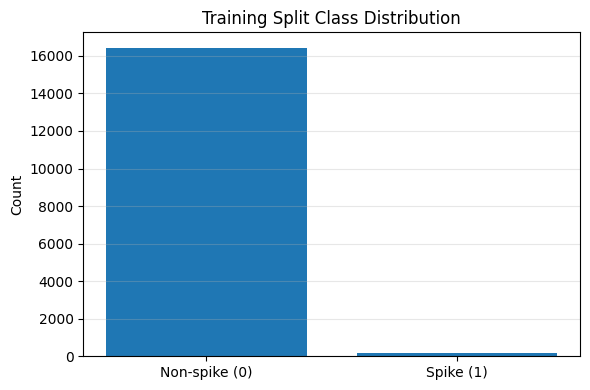

Saved: /content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs/plots/class_imbalance_train.png
Counts:
y
0    16430
1      189
Name: count, dtype: int64
Spike ratio: 0.011372525422708947


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

class_counts = train_df["y"].value_counts().sort_index()
class_labels = ["Non-spike (0)", "Spike (1)"]

plt.figure(figsize=(6, 4))
plt.bar(class_labels, class_counts.values)
plt.ylabel("Count")
plt.title("Training Split Class Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_path = os.path.join(plot_dir, "class_imbalance_train.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)
print("Counts:")
print(class_counts)
print("Spike ratio:", train_df["y"].mean())

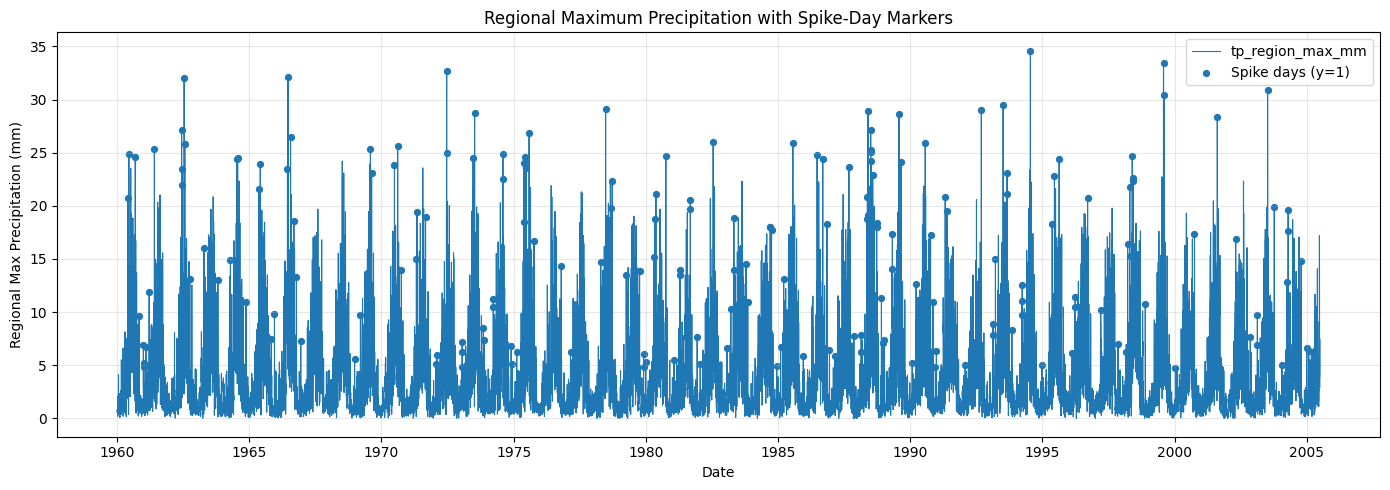

Saved: /content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs/plots/timeseries_tp_region_max_with_spikes.png
Total spike days in plotted dataframe: 189


In [ ]:
import matplotlib.pyplot as plt

# full timeline plot with spike markers
plt.figure(figsize=(14, 5))
plt.plot(df["valid_time"], df["tp_region_max_mm"], linewidth=0.8, label="tp_region_max_mm")

spike_df = df[df["y"] == 1]
plt.scatter(
    spike_df["valid_time"],
    spike_df["tp_region_max_mm"],
    s=18,
    label="Spike days (y=1)"
)

plt.xlabel("Date")
plt.ylabel("Regional Max Precipitation (mm)")
plt.title("Regional Maximum Precipitation with Spike-Day Markers")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

save_path = os.path.join(plot_dir, "timeseries_tp_region_max_with_spikes.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)
print("Total spike days in plotted dataframe:", int(df["y"].sum()))

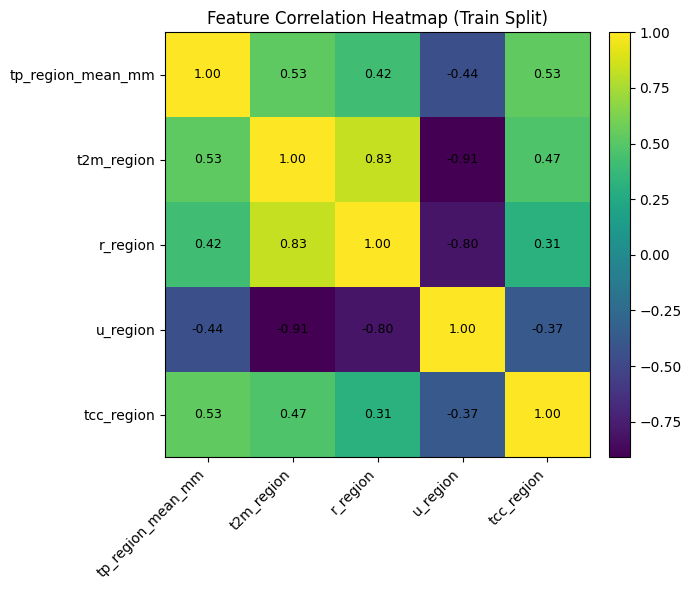

Saved: /content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs/plots/correlation_heatmap_nonleaky_train.png
                   tp_region_mean_mm  t2m_region  r_region  u_region  \
tp_region_mean_mm             1.0000      0.5274    0.4168   -0.4447   
t2m_region                    0.5274      1.0000    0.8291   -0.9095   
r_region                      0.4168      0.8291    1.0000   -0.7990   
u_region                     -0.4447     -0.9095   -0.7990    1.0000   
tcc_region                    0.5348      0.4717    0.3098   -0.3737   

                   tcc_region  
tp_region_mean_mm      0.5348  
t2m_region             0.4717  
r_region               0.3098  
u_region              -0.3737  
tcc_region             1.0000  


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

corr_cols = ["tp_region_mean_mm", "t2m_region", "r_region", "u_region", "tcc_region"]
corr_mat = train_df[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_mat.values, aspect="auto")

ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
ax.set_title("Feature Correlation Heatmap (Train Split)")

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_mat.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

save_path = os.path.join(plot_dir, "correlation_heatmap_nonleaky_train.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)
print(corr_mat.round(4))

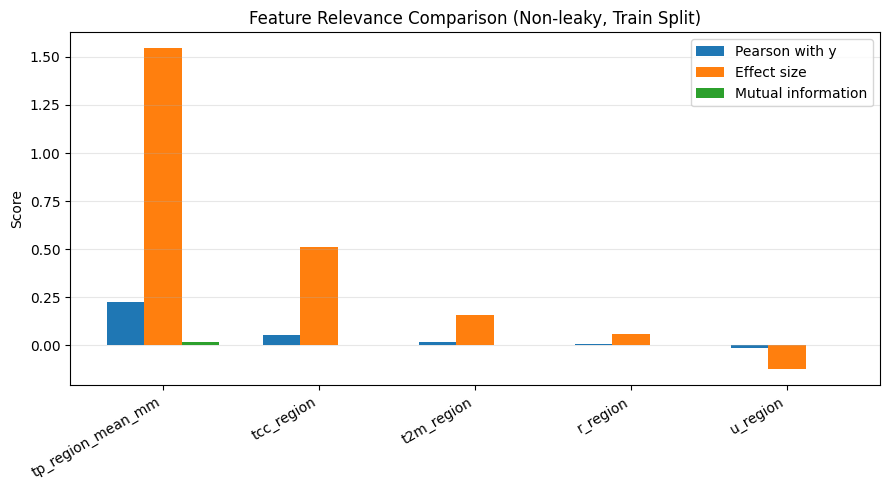

Saved: /content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs/plots/feature_relevance_nonleaky_train.png
             feature  pearson_with_y  effect_size_d  mutual_info
0  tp_region_mean_mm        0.225925       1.543890     0.015254
1         tcc_region        0.052988       0.513079     0.001032
2         t2m_region        0.015824       0.156718     0.000389
3           r_region        0.006299       0.058178     0.000000
4           u_region       -0.012699      -0.123356     0.000000


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = feature_rank_df_fixed.copy()

metrics = ["pearson_with_y", "effect_size_d", "mutual_info"]
x = np.arange(len(plot_df))
width = 0.24

plt.figure(figsize=(9, 5))
plt.bar(x - width, plot_df["pearson_with_y"], width=width, label="Pearson with y")
plt.bar(x,         plot_df["effect_size_d"], width=width, label="Effect size")
plt.bar(x + width, plot_df["mutual_info"],   width=width, label="Mutual information")

plt.xticks(x, plot_df["feature"], rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Feature Relevance Comparison (Non-leaky, Train Split)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

save_path = os.path.join(plot_dir, "feature_relevance_nonleaky_train.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)
print(plot_df.round(6))

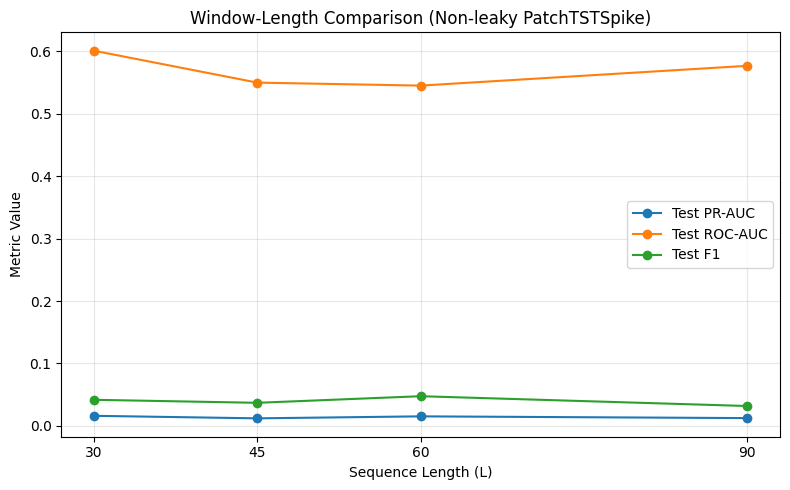

Saved: /content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs/plots/window_length_comparison_nonleaky.png
    L  Test_PR_AUC  Test_ROC_AUC   Test_F1
0  30     0.016226      0.600733  0.041885
1  45     0.012179      0.549670  0.037037
2  60     0.015355      0.544864  0.047619
3  90     0.012570      0.576554  0.031915


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(results_df_nonleaky["L"], results_df_nonleaky["Test_PR_AUC"], marker="o", label="Test PR-AUC")
plt.plot(results_df_nonleaky["L"], results_df_nonleaky["Test_ROC_AUC"], marker="o", label="Test ROC-AUC")
plt.plot(results_df_nonleaky["L"], results_df_nonleaky["Test_F1"], marker="o", label="Test F1")

plt.xlabel("Sequence Length (L)")
plt.ylabel("Metric Value")
plt.title("Window-Length Comparison (Non-leaky PatchTSTSpike)")
plt.xticks(results_df_nonleaky["L"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

save_path = os.path.join(plot_dir, "window_length_comparison_nonleaky.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)
print(results_df_nonleaky[["L", "Test_PR_AUC", "Test_ROC_AUC", "Test_F1"]].round(6))

In [ ]:
print("test_metrics_30 keys:", list(test_metrics_30.keys()))


test_metrics_30 keys: ['roc_auc', 'pr_auc', 'best_th', 'f1', 'precision', 'recall']


In [ ]:
import numpy as np
import torch

model_30.eval()

y_true_30 = []
y_score_30 = []

with torch.no_grad():
    for xb, yb in test_loader_30:
        xb = xb.to(device).float()
        logits = model_30(xb)
        probs = torch.sigmoid(logits).detach().cpu().numpy()

        y_true_30.extend(yb.numpy().tolist())
        y_score_30.extend(probs.tolist())

y_true_30 = np.array(y_true_30)
y_score_30 = np.array(y_score_30)

print("Collected shapes:", y_true_30.shape, y_score_30.shape)
print("Positive rate in y_true_30:", y_true_30.mean())
print("Score range:", float(y_score_30.min()), "to", float(y_score_30.max()))

Collected shapes: (3532,) (3532,)
Positive rate in y_true_30: 0.008493771234428085
Score range: 0.01872532069683075 to 0.9913188815116882


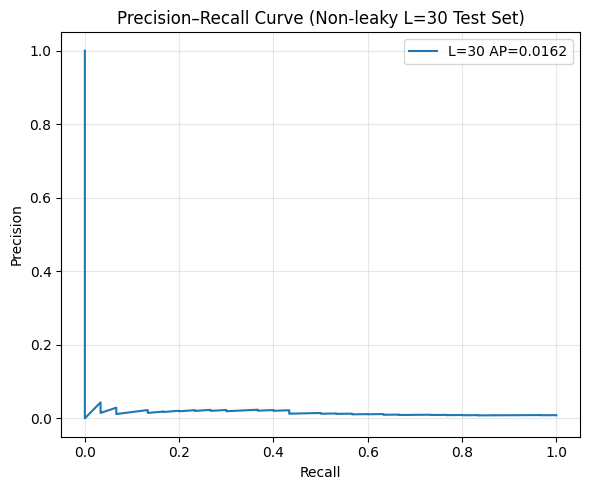

Saved: /content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs/plots/pr_curve_nonleaky_L30_test.png
Average Precision (AP): 0.01622582591117444


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision_30, recall_30, _ = precision_recall_curve(y_true_30, y_score_30)
ap_30 = average_precision_score(y_true_30, y_score_30)

plt.figure(figsize=(6, 5))
plt.plot(recall_30, precision_30, label=f"L=30 AP={ap_30:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Non-leaky L=30 Test Set)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

save_path = os.path.join(plot_dir, "pr_curve_nonleaky_L30_test.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)
print("Average Precision (AP):", ap_30)

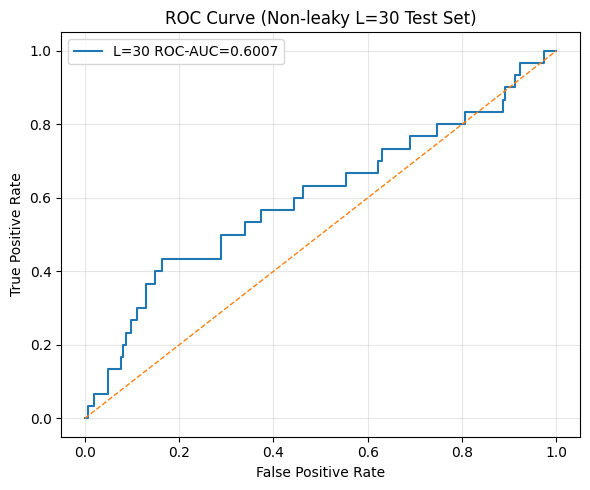

Saved: /content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs/plots/roc_curve_nonleaky_L30_test.png
ROC-AUC: 0.6007329145250333


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr_30, tpr_30, _ = roc_curve(y_true_30, y_score_30)
roc_auc_30 = roc_auc_score(y_true_30, y_score_30)

plt.figure(figsize=(6, 5))
plt.plot(fpr_30, tpr_30, label=f"L=30 ROC-AUC={roc_auc_30:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Non-leaky L=30 Test Set)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

save_path = os.path.join(plot_dir, "roc_curve_nonleaky_L30_test.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)
print("ROC-AUC:", roc_auc_30)

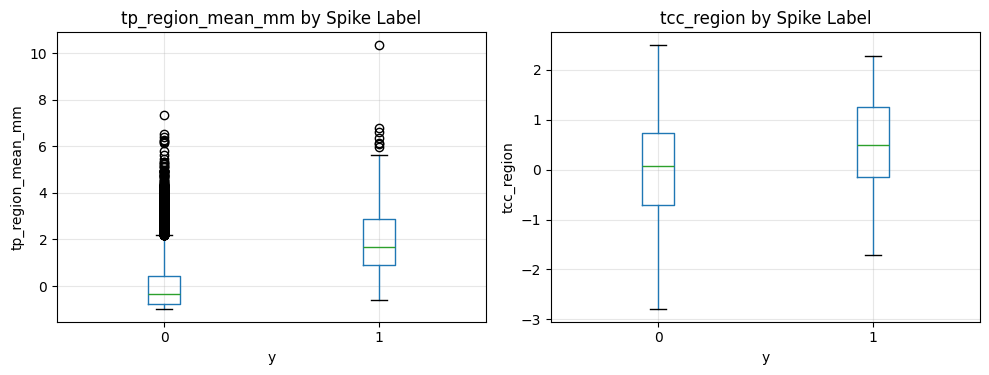

Saved: /content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs/plots/boxplots_top_features_nonleaky_train.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train_df.boxplot(column="tp_region_mean_mm", by="y", ax=axes[0])
axes[0].set_title("tp_region_mean_mm by Spike Label")
axes[0].set_xlabel("y")
axes[0].set_ylabel("tp_region_mean_mm")
axes[0].grid(alpha=0.3)

train_df.boxplot(column="tcc_region", by="y", ax=axes[1])
axes[1].set_title("tcc_region by Spike Label")
axes[1].set_xlabel("y")
axes[1].set_ylabel("tcc_region")
axes[1].grid(alpha=0.3)

plt.suptitle("")
plt.tight_layout()

save_path = os.path.join(plot_dir, "boxplots_top_features_nonleaky_train.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


In [ ]:
import os

plot_files = sorted([
    f for f in os.listdir(plot_dir)
    if f.endswith(".png")
])

print("Saved plot files:")
for f in plot_files:
    print("-", f)

Saved plot files:
- boxplots_top_features_nonleaky_train.png
- class_imbalance_train.png
- correlation_heatmap_nonleaky_train.png
- feature_relevance_nonleaky_train.png
- pr_curve_nonleaky_L30_test.png
- roc_curve_nonleaky_L30_test.png
- timeseries_tp_region_max_with_spikes.png
- window_length_comparison_nonleaky.png


In [ ]:
plot_list_path = os.path.join(plot_dir, "plot_file_list.txt")

with open(plot_list_path, "w") as f:
    for name in plot_files:
        f.write(name + "\n")

print("Saved:", plot_list_path)

Saved: /content/drive/MyDrive/Colab Notebooks/multivariate_rainfall_prediction/final_nonleaky_outputs/plots/plot_file_list.txt


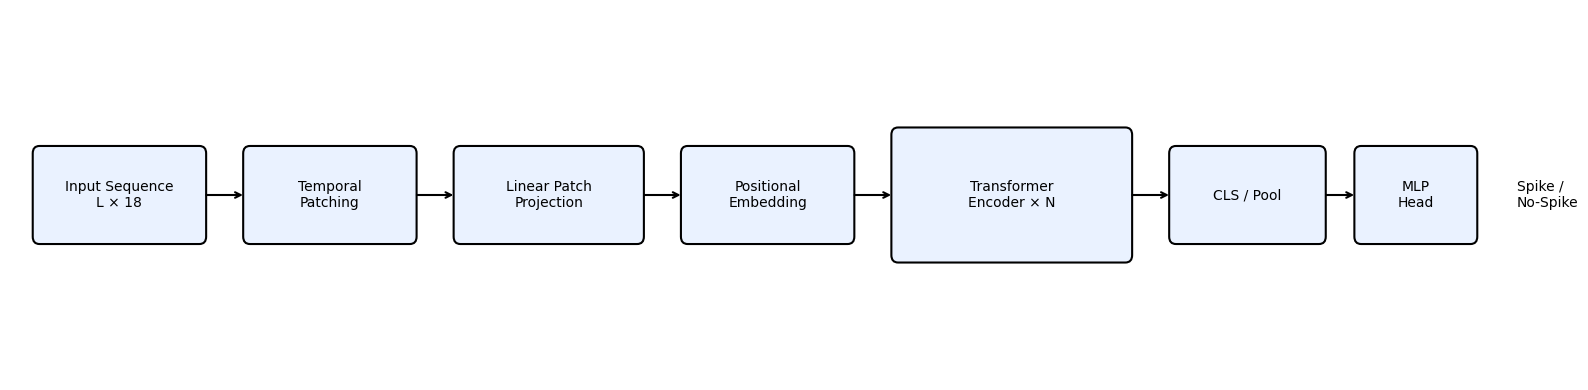

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 18)
ax.set_ylim(0, 4)
ax.axis("off")

boxes = [
    (0.3, 1.5, 2.0, 1.0, "Input Sequence\nL × 18"),
    (2.8, 1.5, 2.0, 1.0, "Temporal\nPatching"),
    (5.3, 1.5, 2.2, 1.0, "Linear Patch\nProjection"),
    (8.0, 1.5, 2.0, 1.0, "Positional\nEmbedding"),
    (10.5, 1.3, 2.8, 1.4, "Transformer\nEncoder × N"),
    (13.8, 1.5, 1.8, 1.0, "CLS / Pool"),
    (16.0, 1.5, 1.4, 1.0, "MLP\nHead"),
]

for x, y, w, h, label in boxes:
    rect = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.5,
        edgecolor="black",
        facecolor="#eaf2ff"
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=10)

for i in range(len(boxes)-1):
    x1 = boxes[i][0] + boxes[i][2]
    y1 = boxes[i][1] + boxes[i][3]/2
    x2 = boxes[i+1][0]
    y2 = boxes[i+1][1] + boxes[i+1][3]/2
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.5))

ax.text(17.9, 2.0, "Spike /\nNo-Spike", ha="left", va="center", fontsize=10)

plt.tight_layout()
plt.show()